# Qwen3-4B Explainable Phishing Detection — Clean Run-All Notebook

Run `Runtime → Run all` in Google Colab.

This notebook:
1. Loads the 147,524-row phishing/benign JSONL dataset.
2. Builds a full-dataset mutual-information report over all 126 feature columns.
3. Drops only features selected by the MI/quality audit configuration.
4. Creates subdomain-level domain-disjoint train/validation/test splits using full hostnames.
5. Fine-tunes Qwen3-4B with QLoRA.
6. Evaluates classification and explanation quality on held-out subdomains.
7. Saves the adapter, metrics, reports, plots, gold-review candidates, and model card.


In [ ]:
!nvidia-smi
!pip -q install -U "transformers>=4.51.0" datasets accelerate peft trl scikit-learn \
    huggingface_hub "bitsandbytes>=0.46.1" matplotlib



Tue Jun  9 07:21:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   46C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import sklearn
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression

print("sklearn:", sklearn.__version__)
print("sklearn imports OK")

sklearn: 1.9.0
sklearn imports OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import gc
import os
import re
import csv
import math
import json
import random
import logging
from pathlib import Path
from statistics import mean

import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, concatenate_datasets
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    precision_recall_curve, average_precision_score,
)
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    StoppingCriteria,
    StoppingCriteriaList,
)
from peft import (
    LoraConfig,
    PeftModel,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

LOGGER = logging.getLogger("qwen3_explainable")
if not LOGGER.handlers:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

print("Device:", device)
print("PyTorch:", torch.__version__)
print("Compute dtype:", compute_dtype)


Device: cuda
PyTorch: 2.11.0+cu128
Compute dtype: torch.bfloat16


In [ ]:
# =============================================================
# Config  —  edit here, then Run All
# =============================================================
from datetime import datetime

DATASET_PATH          = "/content/drive/MyDrive/50k.jsonl"
OUT_FEATURES_PATH     = "/content/drive/MyDrive/out_features.jsonl"  # set None to skip join
RUN_ROOT              = Path("/content/drive/MyDrive/qwen3_explainable_runs")
RUN_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_ID              = "Qwen/Qwen3-4B"
MAX_LEN               = 3072         # supports compact use of all selected dataset features
N_EACH                = 25000         # examples per class — raised for 50k dataset (~59k phishing available)
MAX_PER_SUBDOMAIN     = 1           # max training examples from one full hostname/subdomain
VISIBLE_TEXT_CHARS    = 500           # shorter text → shorter sequences → faster training & fewer truncations
MAX_CLEAN_TEXT_CHARS  = 5000          # room for URL/title plus compact selected feature vector

INCLUDE_SIGNALS_IN_TRAIN_PROMPT = False
INCLUDE_SIGNALS_IN_EVAL_PROMPT  = False
MAX_SIGNALS_IN_PROMPT           = 0

# Feature selection after full-dataset MI analysis.
# The notebook first audits all 126 dataset features, then builds prompts/signals
# from the selected feature dictionary. Keep MI_MIN_SCORE_TO_KEEP=0.0 to drop
# only constant/mostly-missing fields; raise it for a smaller and faster input.
MI_DROP_CONSTANT_OR_MISSING = True
MI_MISSING_RATE_DROP        = 0.99
MI_MIN_SCORE_TO_KEEP        = 0.0
KEEP_NON_NUMERIC_FEATURES   = True

# Training
NUM_TRAIN_EPOCHS              = 3     # faster final run; previous training stopped around epoch 3
EARLY_STOPPING_PATIENCE       = 2    # faster stop when validation loss plateaus
PER_DEVICE_TRAIN_BATCH_SIZE   = 8    # can fit larger batch with shorter sequences
PER_DEVICE_EVAL_BATCH_SIZE    = 4
TRAINER_VAL_MAX_SAMPLES       = 1000 # capped loss-eval set for speed; full val still used later
GRADIENT_ACCUMULATION_STEPS   = 4    # halved because shorter seqs free VRAM; effective batch stays 32
LEARNING_RATE                 = 1e-4
IDENTITY_RISK_OVERSAMPLE_FACTOR = 1
LEGIT_SSO_OVERSAMPLE_FACTOR     = 1

# Evaluation
EVAL_MAX_SAMPLES              = 200    # test set cap (×2=400); set to 1000 for final eval only
ZEROSHOT_EVAL_MAX_SAMPLES     = 200   # zero-shot is slow — keep capped
TUNED_EVAL_MAX_SAMPLES        = 7000  # full held-out test; dataset has 6634 after filtering
EVAL_GENERATION_BATCH_SIZE    = 8     # A100-friendly batched generation
EVAL_COMPUTE_CONFIDENCE       = False # False is much faster; AUC-PR will be None
GEN_MAX_NEW_TOKENS            = 180   # enough room for feature lists + reasoning + verdict
GOLD_SAMPLE_SIZE              = 100
MAX_RETRIES_ON_PARSE_FAIL     = 0    # no retries during training runs; set to 2 for final eval
RUN_ZERO_SHOT_BASELINE        = False # set True to compare baseline vs fine-tuned (adds ~15 min)

# Learning curve — trains Qwen3-4B at multiple dataset fractions (expensive: ~1h per fraction).
# Set True only for final thesis results. Each fraction uses the same QLoRA config as the main run.
RUN_LLM_LEARNING_CURVE        = False
LLM_LC_FRACTIONS              = [0.10, 0.25, 0.50, 1.00]  # fractions of training set to use

# Classification threshold — lower values favour recall (catching more phishing)
# at the cost of precision.  0.5 = equal cost; try 0.4 to reduce false negatives.
PHISHING_THRESHOLD            = 0.5

# Split fractions — applied to the full dataset before the training cap.
# Splits are random-stratified, then validation/test hostnames are removed
# if the exact same hostname/subdomain appears in training.
# This means test/val sizes reflect real data volume, not the N_EACH training limit.
TEST_FRAC             = 0.20          # fraction of full pool → test set
VAL_FRAC              = 0.10          # fraction of full pool → validation set
N_FULL_PER_CLASS      = None          # None = use all; set int to cap the split pool

# Taxonomy enforcement — if True, predicted features NOT in KNOWN_FEATURE_TAXONOMY
# are removed before evaluation, which eliminates hallucinated feature-name noise.
ENFORCE_TAXONOMY              = True

# Multi-seed (set True for final results; False for dev runs — 3x longer)
MULTI_SEED = False
SEEDS      = [42, 123, 777]
SEED       = SEEDS[0]

# ── Quick-test mode ───────────────────────────────────────────────────────────
# Flip to True for a fast pipeline check (~6-8 min on Colab A100).
# Everything runs end-to-end but with a tiny dataset — do NOT use for real results.
# Set back to False for the actual experiment (~78 min).
QUICK_TEST_MODE = False

if QUICK_TEST_MODE:
    N_EACH                = 100    # tiny sample — just enough to exercise every cell
    N_FULL_PER_CLASS      = 500    # small split pool so quick-test stays fast
    ZEROSHOT_EVAL_MAX_SAMPLES = 30
    TUNED_EVAL_MAX_SAMPLES    = 50
    EVAL_MAX_SAMPLES      = 30     # fast eval pass
    NUM_TRAIN_EPOCHS      = 1      # single epoch
    EARLY_STOPPING_PATIENCE = 2
    RUN_ZERO_SHOT_BASELINE  = False  # skip zero-shot to halve model-load time
    GOLD_SAMPLE_SIZE        = 10
    MAX_RETRIES_ON_PARSE_FAIL = 0   # no retries — speed
    print("\n" + "!"*70)
    print("  QUICK_TEST_MODE=True — reduced dataset for pipeline check ONLY.")
    print("  Set QUICK_TEST_MODE=False for real experiment results.")
    print("!"*70 + "\n")
    print("Switch to False for the real experiment.")

RUN_NAME = f"qwen3_4b_explainable_seed{SEED}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR  = RUN_ROOT / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)

print("RUN_DIR:", RUN_DIR)
print("MODEL_ID:", MODEL_ID)
print("Leakage-safe prompts:", not INCLUDE_SIGNALS_IN_TRAIN_PROMPT and not INCLUDE_SIGNALS_IN_EVAL_PROMPT)
print(f"Context: visible_text={VISIBLE_TEXT_CHARS} chars | total_clean={MAX_CLEAN_TEXT_CHARS} chars")
print(f"Training: up to {NUM_TRAIN_EPOCHS} epochs, early-stop patience={EARLY_STOPPING_PATIENCE}")
print(f"Eval samples: {EVAL_MAX_SAMPLES} | Zero-shot baseline: {RUN_ZERO_SHOT_BASELINE}")
print("Split: random stratified, then hostname/subdomain-disjoint filtering")
print(f"Phishing threshold: {PHISHING_THRESHOLD} | Taxonomy enforcement: {ENFORCE_TAXONOMY}")
print(f"Feature MI: drop_constant={MI_DROP_CONSTANT_OR_MISSING} | min_mi={MI_MIN_SCORE_TO_KEEP}")


RUN_DIR: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260609_072223
MODEL_ID: Qwen/Qwen3-4B
Leakage-safe prompts: True
Context: visible_text=500 chars | total_clean=5000 chars
Training: up to 3 epochs, early-stop patience=2
Eval samples: 200 | Zero-shot baseline: False
Split: random stratified, then hostname/subdomain-disjoint filtering
Phishing threshold: 0.5 | Taxonomy enforcement: True
Feature MI: drop_constant=True | min_mi=0.0


In [ ]:
# Load tokenizer only here — model loading is deferred so we can do
# zero-shot eval first, free VRAM, then reload for training.
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Tokenizer loaded:", MODEL_ID)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Tokenizer loaded: Qwen/Qwen3-4B


In [ ]:
cleaned_path = RUN_DIR / "output_clean.jsonl"
good, bad = 0, 0
precomputed_nonempty, precomputed_empty = 0, 0

# Build pre-computed signal lookup from out_features.jsonl (87.5% of rows overlap with 50k).
# Pre-computed signals were extracted from full page content (visible text, forms, anchors)
# and are more accurate than signals derived from numerical features alone.
_precomputed_signals = {}
if OUT_FEATURES_PATH:
    try:
        with open(OUT_FEATURES_PATH, encoding="utf-8") as _f:
            for _line in _f:
                _row = json.loads(_line)
                _rid = _row.get("id")
                _feats = _row.get("features")
                if _rid and isinstance(_feats, list):
                    # Keep only id + direction. Empty lists are intentionally NOT stored:
                    # an empty out_features row means "no semantic page signal was extracted",
                    # so preprocessing should fall back to numerical 50k.jsonl features.
                    _signals = [
                        {"id": str(s.get("id","")), "direction": str(s.get("direction",""))}
                        for s in _feats if s.get("id")
                    ]
                    if _signals:
                        _precomputed_signals[_rid] = _signals
                        precomputed_nonempty += 1
                    else:
                        precomputed_empty += 1
        print(
            f"Pre-computed signal lookup built: {len(_precomputed_signals):,} non-empty rows "
            f"from out_features.jsonl; {precomputed_empty:,} empty rows will fall back to numerical features"
        )
    except FileNotFoundError:
        print(f"WARNING: OUT_FEATURES_PATH not found ({OUT_FEATURES_PATH}) — will derive all signals from features")
else:
    print("OUT_FEATURES_PATH=None — deriving all signals from numerical features")

# Keep only primitive-safe fields.
# label_info has variable nested schema: phishing_db rows have {rule, latest_scan: null}
# while urlscan rows add scan_labels and latest_evidence — this causes Arrow type conflicts
# when HuggingFace datasets tries to infer a unified schema across all rows.
# feature_groups is redundant with the flat features dict.
_KEEP = {"id", "label", "url", "final_url", "title", "db", "collection", "features"}

with open(DATASET_PATH, encoding="utf-8") as fin, \
     open(cleaned_path, "w", encoding="utf-8") as fout:
    for line in fin:
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
        except Exception:
            bad += 1
            continue
        label = str(obj.get("label", "")).strip()
        if label not in {"phishing", "benign"}:
            bad += 1
            continue
        out = {k: obj[k] for k in _KEEP if k in obj}
        out["label"] = label
        if obj.get("id") in _precomputed_signals:
            out["precomputed_signals"] = _precomputed_signals[obj["id"]]
        fout.write(json.dumps(out, ensure_ascii=False) + "\n")
        good += 1

print(f"Cleaned: {good:,} rows written, {bad} skipped → {cleaned_path}")

ds = load_dataset("json", data_files=str(cleaned_path), split="train")
print("Loaded:", ds)
print("Columns:", ds.column_names)


Pre-computed signal lookup built: 75,361 non-empty rows from out_features.jsonl; 4,639 empty rows will fall back to numerical features
Cleaned: 147,524 rows written, 0 skipped → /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260609_072223/output_clean.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Loaded: Dataset({
    features: ['id', 'label', 'features', 'db', 'title', 'final_url', 'url', 'collection', 'precomputed_signals'],
    num_rows: 147524
})
Columns: ['id', 'label', 'features', 'db', 'title', 'final_url', 'url', 'collection', 'precomputed_signals']


In [ ]:

# ── Full-dataset MI feature audit and selected feature set ───────────────────
# We audit all feature columns before splitting, then drop only fields selected
# by the audit configuration above. This is intentionally full-dataset analysis:
# report it as preprocessing/feature selection, not as a training-only selector.
#
# Implementation note: build a feature dataframe once. Iterating a Hugging Face
# Dataset once per feature is very slow in Colab; this path is much faster.
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

_feature_rows = ds["features"]
_label_rows = ds["label"]
_feature_df_raw = pd.DataFrame.from_records(_feature_rows)
_all_feature_names = sorted(_feature_df_raw.columns.tolist())
_y_all = np.array([1 if label == "phishing" else 0 for label in _label_rows], dtype=np.int32)

_numeric_df = _feature_df_raw.apply(pd.to_numeric, errors="coerce")
_mi_rows = []
for _name in _all_feature_names:
    _arr = _numeric_df[_name]
    _valid = _arr.notna()
    _missing_rate = float((~_valid).mean())
    _n_unique = int(_arr[_valid].nunique()) if _valid.any() else 0
    _non_numeric = int(_feature_df_raw[_name].notna().sum() - _valid.sum())

    if _valid.sum() == 0 or _n_unique <= 1:
        _mi = 0.0
    else:
        _median = _arr[_valid].median()
        _filled = _arr.fillna(_median).to_numpy(dtype="float64").reshape(-1, 1)
        _mi = float(mutual_info_classif(_filled, _y_all, discrete_features=False, random_state=SEED)[0])

    _drop_quality = bool(MI_DROP_CONSTANT_OR_MISSING and (_n_unique <= 1 or _missing_rate > MI_MISSING_RATE_DROP))
    _drop_mi = bool(_non_numeric == 0 and _mi < MI_MIN_SCORE_TO_KEEP)
    _drop_non_numeric = bool(_non_numeric > 0 and not KEEP_NON_NUMERIC_FEATURES)
    _mi_rows.append({
        "feature": _name,
        "mi_score": _mi,
        "n_unique": _n_unique,
        "missing_rate": _missing_rate,
        "non_numeric_rows": _non_numeric,
        "drop": bool(_drop_quality or _drop_mi or _drop_non_numeric),
        "drop_reason": (
            "constant_or_mostly_missing" if _drop_quality else
            "below_mi_threshold" if _drop_mi else
            "non_numeric" if _drop_non_numeric else
            ""
        ),
    })

raw_feature_mi_df = pd.DataFrame(_mi_rows).sort_values("mi_score", ascending=False)
SELECTED_FEATURE_NAMES = raw_feature_mi_df.loc[~raw_feature_mi_df["drop"], "feature"].tolist()
DROPPED_FEATURE_NAMES = raw_feature_mi_df.loc[raw_feature_mi_df["drop"], "feature"].tolist()

print(f"Dataset feature audit: {len(_all_feature_names)} total features")
print(f"Selected for model input: {len(SELECTED_FEATURE_NAMES)}")
print(f"Dropped after MI/quality audit: {len(DROPPED_FEATURE_NAMES)}")
display(raw_feature_mi_df.head(40))
if DROPPED_FEATURE_NAMES:
    display(raw_feature_mi_df[raw_feature_mi_df["drop"]].sort_values(["drop_reason", "mi_score"]))

feature_audit_path = RUN_DIR / "feature_mi_audit.csv"
selected_features_path = RUN_DIR / "selected_features.json"
raw_feature_mi_df.to_csv(feature_audit_path, index=False)
with open(selected_features_path, "w", encoding="utf-8") as _f:
    json.dump({
        "selected_features": SELECTED_FEATURE_NAMES,
        "dropped_features": DROPPED_FEATURE_NAMES,
        "mi_min_score_to_keep": MI_MIN_SCORE_TO_KEEP,
        "mi_missing_rate_drop": MI_MISSING_RATE_DROP,
    }, _f, indent=2, ensure_ascii=False)
print("Feature audit saved to:", feature_audit_path)
print("Selected feature list saved to:", selected_features_path)

del _feature_rows, _label_rows, _feature_df_raw, _numeric_df

def filter_selected_features(feats):
    feats = feats or {}
    return {k: feats.get(k) for k in SELECTED_FEATURE_NAMES if k in feats}

def _fmt_feature_value(v):
    if isinstance(v, float):
        return f"{v:.4g}"
    if isinstance(v, bool):
        return int(v)
    return v

def compact_feature_vector(feats):
    return "Selected feature vector: " + " | ".join(
        f"{k}={_fmt_feature_value(v)}" for k, v in sorted((feats or {}).items())
    )


def _items_list(obj):
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        items = obj.get("items", [])
        return items if isinstance(items, list) else []
    return []

# ── Signal derivation from numerical features (50k.jsonl format) ─────────────
def features_to_signals(feats):
    """Derive semantic signal IDs from extracted numerical features."""
    sigs = []
    def add(fid, direction):
        sigs.append({"id": fid, "direction": direction})

    # ── URL signals ──────────────────────────────────────────────────────────
    if not feats.get("url.scheme_is_https", 1):
        add("url.http_not_https", "suspicious")
    if feats.get("url.host_is_ip_address", 0):
        add("url.long_url", "suspicious")           # IP host = no legitimate domain
    if feats.get("url.at_sign_count", 0) > 0:
        add("url.email_identifier", "suspicious")
    if (feats.get("url.punycode_present", 0)
            or feats.get("url.https_token_in_hostname", 0)
            or feats.get("url.extra_double_slash_count", 0) > 0
            or feats.get("url.percent_sign_count", 0) > 3):
        add("url.homograph_or_unicode_hostname", "suspicious")
    if feats.get("url.subdomain_label_count", 0) >= 3:
        add("url.deep_subdomain", "suspicious")
    if feats.get("url.requested_url_length", 0) > 75:
        add("url.long_url", "benign")               # long URLs are more common on benign pages

    # ── Credential / Form signals ─────────────────────────────────────────────
    if feats.get("html.password_input_count", 0) > 0:
        add("credential.password_input_present", "suspicious")
    if feats.get("html.credential_form_present", 0):
        add("credential.credential_terms_near_form", "suspicious")
    if (feats.get("html.external_form_action_count", 0) > 0
            or feats.get("html.password_form_external_action_present", 0)):
        add("form.external_action", "suspicious")
    if feats.get("html.hidden_input_count", 0) > 0:
        add("form.hidden_inputs", "suspicious")
    if (feats.get("html.null_form_action_count", 0) > 0
            or feats.get("html.password_form_null_action_present", 0)):
        add("form.empty_or_blank_action", "suspicious")
    # mailto form action = submits credentials to email address (classic phishing)
    if feats.get("html.mailto_form_action_count", 0) > 0:
        add("form.external_action", "suspicious")
    # form with no submit button = JS-driven invisible submission
    if (feats.get("html.form_count", 0) > 0
            and feats.get("html.submit_button_count", 0) == 0):
        add("form.blank_action_js_submission_suspected", "suspicious")

    # ── Link signals ──────────────────────────────────────────────────────────
    if (feats.get("html.external_anchor_ratio", 0.0) > 0.5
            and feats.get("html.anchors_with_href_count", 0) > 2):
        add("link.high_external_anchor_ratio", "suspicious")
    if (feats.get("html.null_or_empty_anchor_count", 0) > 0
            or feats.get("html.anchors_missing_href_count", 0) > 0
            or feats.get("html.placeholder_link_ratio", 0.0) > 0.5):
        add("link.null_or_void_anchors", "suspicious")
    if feats.get("html.onmouseover_handler_count", 0) > 0:
        add("link.null_or_void_anchors", "suspicious")  # onmouseover = link spoofing

    # ── JS / obfuscation signals ──────────────────────────────────────────────
    js_obfusc = (feats.get("html.eval_call_count", 0) > 0
                 or feats.get("html.atob_call_count", 0) > 0
                 or feats.get("html.document_write_count", 0) > 0)
    if js_obfusc or feats.get("html.right_click_disabling_present", 0):
        add("page.rendering_incomplete_or_script_dependent", "suspicious")
    if feats.get("html.alert_or_popup_present", 0):
        add("content.coercive_urgency_near_form", "suspicious")

    # ── Redirect / metadata signals ───────────────────────────────────────────
    if (feats.get("metadata.redirect_domain_change_count", 0) > 0
            or feats.get("metadata.final_scheme_changed", 0)
            or feats.get("html.javascript_redirect_present", 0)
            or feats.get("metadata.final_host_changed", 0)
            or feats.get("url.path_or_query_contains_url", 0)):
        add("redirect.cross_domain", "suspicious")
    if feats.get("metadata.redirect_count", 0) > 1 or feats.get("html.meta_refresh_count", 0) > 0:
        add("redirect.multi_hop", "suspicious")

    # ── Page / content signals ────────────────────────────────────────────────
    words = feats.get("html.visible_word_count", 0)
    if words < 30:
        add("page.low_semantic_content", "suspicious")
    # zero headings AND zero paragraphs with a form = structurally empty phishing page
    if (feats.get("html.heading_h1_h2_h3_count", 0) == 0
            and feats.get("html.paragraph_count", 0) == 0
            and feats.get("html.form_count", 0) > 0):
        add("page.low_semantic_content", "suspicious")
    if words < 50 and feats.get("html.form_count", 0) > 0:
        add("page.generic_login_without_brand_claim", "suspicious")
    # password form with no privacy/terms link and no navigation = missing recovery flow
    if (feats.get("html.form_count", 0) > 0
            and feats.get("html.password_input_count", 0) > 0
            and feats.get("html.privacy_or_terms_link_present", 0) == 0
            and feats.get("html.navigation_present", 0) == 0):
        add("login.missing_recovery_or_help_flow", "suspicious")

    # ── Benign signals ────────────────────────────────────────────────────────
    if (feats.get("html.navigation_present", 0)
            or feats.get("html.internal_anchor_count", 0) > 5):
        add("navigation.functional_internal_links", "benign")
    if (feats.get("html.footer_present", 0)
            or feats.get("html.privacy_or_terms_link_present", 0)):
        add("support.contact_domain_match", "benign")
    # form action points to same org: form exists, not external, not null → benign trust signal
    if (feats.get("html.form_count", 0) > 0
            and feats.get("html.external_form_action_count", 0) == 0
            and feats.get("html.null_form_action_count", 0) == 0
            and feats.get("html.password_form_external_action_present", 0) == 0):
        add("form.action_same_org_domain", "benign")
    if feats.get("html.external_iframe_count", 0) > 0:
        add("iframe.hidden_iframe", "suspicious")
    elif feats.get("html.iframe_count", 0) > 0:
        add("iframe.hidden_iframe", "benign")

    # ── Brand / title signals ─────────────────────────────────────────────────
    if (feats.get("html.title_registered_domain_token_present", 0)
            or feats.get("html.title_url_token_overlap_ratio", 0.0) > 0.7):
        add("brand.title_domain_match_strong", "benign")
    elif (feats.get("html.title_length", 0) > 5
            and not feats.get("html.current_domain_token_in_title", 0)):
        add("brand.title_domain_mismatch", "suspicious")
    # subdomain token in title but registered domain is absent → impersonation via subdomain
    if (feats.get("html.title_subdomain_token_present", 0)
            and not feats.get("html.title_registered_domain_token_present", 0)):
        add("brand.title_domain_mismatch", "suspicious")
    # external favicon = brand impersonation (favicon served from different domain)
    if feats.get("html.external_favicon_count", 0) > 0:
        add("brand.favicon_domain_mismatch", "suspicious")
    # multiple hyphens in registrable domain → constructed lookalike (e.g. pay-pal-login.com)
    if feats.get("url.registrable_domain_hyphen_count", 0) >= 2:
        add("brand.domain_lookalike", "suspicious")

    # De-duplicate by id
    seen, out = set(), []
    for s in sigs:
        if s["id"] not in seen:
            seen.add(s["id"])
            out.append(s)
    return out


def _feat_clean_text(url, final_url, title, feats):
    """Build structured prompt text from URL, title, and numerical features."""
    lines = []
    if url:
        lines.append(f"URL: {url}")
    host = url.split("//", 1)[1].split("/")[0] if "//" in url else ""
    if host:
        lines.append(f"Hostname: {host}")
    if title:
        lines.append(f"Page title: {title}")
    lines.append(compact_feature_vector(feats))

    # ── URL patterns ──────────────────────────────────────────────────────────
    url_flags = []
    if feats.get("url.host_is_ip_address", 0):
        url_flags.append("IP host")
    if feats.get("url.at_sign_count", 0):
        url_flags.append(f"@ sign ({feats['url.at_sign_count']})")
    if feats.get("url.https_token_in_hostname", 0):
        url_flags.append("'https' in hostname")
    if feats.get("url.punycode_present", 0):
        url_flags.append("punycode")
    sub_len  = feats.get("url.subdomain_length", 0)
    sub_lbls = feats.get("url.subdomain_label_count", 0)
    entropy  = feats.get("url.character_entropy", 0.0)
    dig_r    = feats.get("url.digit_ratio", 0.0)
    hyphens  = feats.get("url.hyphen_count", 0)
    url_len  = feats.get("url.requested_url_length", 0)
    host_len    = feats.get("url.hostname_length", 0)
    dom_hyphens = feats.get("url.registrable_domain_hyphen_count", 0)
    non_def_port = feats.get("url.non_default_port_present", 0)
    url_in_url  = feats.get("url.path_or_query_contains_url", 0)
    if non_def_port:  url_flags.append("non-default port")
    if url_in_url:    url_flags.append("URL-in-URL")
    pct_enc   = feats.get("url.percent_sign_count", 0)
    dbl_slash = feats.get("url.extra_double_slash_count", 0)
    if pct_enc > 3:   url_flags.append(f"pct-encoded({pct_enc})")
    if dbl_slash > 0: url_flags.append(f"double-slash({dbl_slash})")
    path_len  = feats.get("url.path_length", 0)
    path_segs = feats.get("url.path_segment_count", 0)
    q_len     = feats.get("url.query_length", 0)
    q_params  = feats.get("url.query_parameter_count", 0)
    final_len = feats.get("url.final_url_length", 0)
    dom_len   = feats.get("url.registrable_domain_length", 0)
    host_digs = feats.get("url.hostname_digit_count", 0)
    expl_port = feats.get("url.explicit_port_present", 0)
    if expl_port: url_flags.append("explicit port")
    lines.append(
        f"URL patterns: length={url_len} (final={final_len}) | hostname={host_len} chars "
        f"({host_digs} digits) | domain_len={dom_len} | "
        f"subdomain={sub_len} chars, {sub_lbls} labels | domain_hyphens={dom_hyphens} | "
        f"path={path_len} chars, {path_segs} segments | query={q_len} chars, {q_params} params | "
        f"entropy={entropy:.2f} | digit_ratio={dig_r:.2f} | hyphens={hyphens}"
        + (f" | flags: {', '.join(url_flags)}" if url_flags else "")
    )

    # ── Page structure ────────────────────────────────────────────────────────
    tags     = feats.get("html.total_tag_count", 0)
    unique   = feats.get("html.unique_tag_count", 0)
    scripts  = feats.get("html.script_tag_count", 0)
    ext_s    = feats.get("html.external_script_count", 0)
    inline_s = feats.get("html.inline_script_count", 0)
    imgs     = feats.get("html.image_count", 0)
    meta     = feats.get("html.meta_tag_count", 0)
    headings = feats.get("html.heading_h1_h2_h3_count", 0)
    paras    = feats.get("html.paragraph_count", 0)
    ext_iframes = feats.get("html.external_iframe_count", 0)
    iframes      = feats.get("html.iframe_count", 0)
    ext_imgs     = feats.get("html.external_image_count", 0)
    lines.append(
        f"Page structure: {tags} tags, {unique} unique | "
        f"{scripts} scripts ({ext_s} external, {inline_s} inline) | "
        f"{imgs} images ({ext_imgs} ext) | {iframes} iframes ({ext_iframes} ext) | "
        f"{meta} meta tags | {headings} headings | {paras} paragraphs"
    )

    # ── Links ─────────────────────────────────────────────────────────────────
    anchors    = feats.get("html.anchors_with_href_count", 0)
    missing_href = feats.get("html.anchors_missing_href_count", 0)
    internal   = feats.get("html.internal_anchor_count", 0)
    external   = feats.get("html.external_anchor_count", 0)
    ext_ratio  = feats.get("html.external_anchor_ratio", 0.0)
    ext_int_r  = feats.get("html.external_to_internal_anchor_ratio", 0.0)
    placeholder = feats.get("html.null_or_empty_anchor_count", 0)
    ph_ratio   = feats.get("html.placeholder_link_ratio", 0.0)
    lines.append(
        f"Links: {anchors} with href, {missing_href} missing href | "
        f"{internal} internal, {external} external ({ext_ratio:.0%}) | "
        f"ext/int ratio={ext_int_r:.1f} | {placeholder} empty/placeholder ({ph_ratio:.0%})"
    )

    # ── Forms ─────────────────────────────────────────────────────────────────
    forms      = feats.get("html.form_count", 0)
    inputs     = feats.get("html.input_count", 0)
    pwd        = feats.get("html.password_input_count", 0)
    email_in   = feats.get("html.email_input_count", 0)
    txt_in     = feats.get("html.text_input_count", 0)
    ext_action = feats.get("html.external_form_action_count", 0)
    null_action = feats.get("html.null_form_action_count", 0)
    hidden     = feats.get("html.hidden_input_count", 0)
    hidden_r   = feats.get("html.hidden_input_ratio", 0.0)
    submit_btn = feats.get("html.submit_button_count", 0)
    cred_form  = feats.get("html.credential_form_present", 0)
    pw_ext     = feats.get("html.password_form_external_action_present", 0)
    mailto_action = feats.get("html.mailto_form_action_count", 0)
    post_forms    = feats.get("html.post_form_count", 0)
    pw_null       = feats.get("html.password_form_null_action_present", 0)
    lines.append(
        f"Forms: {forms} form(s), {post_forms} POST, {submit_btn} submit btn(s) | "
        f"{inputs} inputs ({pwd} password, {email_in} email, {txt_in} text) | "
        f"{hidden} hidden ({hidden_r:.0%}) | "
        f"{ext_action} external action, {null_action} null action, {mailto_action} mailto"
        + (" | credential form" if cred_form else "")
        + (" | password→external" if pw_ext else "")
        + (" | password→null" if pw_null else "")
    )

    # ── Resources ────────────────────────────────────────────────────────────
    ext_res_r  = feats.get("html.external_resource_ratio", 0.0)
    ext_img_r  = feats.get("html.external_image_ratio", 0.0)
    ext_css_r  = feats.get("html.external_stylesheet_ratio", 0.0)
    ext_script_r = feats.get("html.external_script_ratio", 0.0)
    uniq_dom   = feats.get("html.unique_external_resource_domain_count", 0)
    fav_total = feats.get("html.favicon_count", 0)
    fav_ext   = feats.get("html.external_favicon_count", 0)
    lines.append(
        f"Resources: ext_ratio={ext_res_r:.0%} | images={ext_img_r:.0%} ext | "
        f"css={ext_css_r:.0%} ext | scripts={ext_script_r:.0%} ext | "
        f"{uniq_dom} unique external domains | favicons={fav_total} ({fav_ext} external)"
    )

    # ── Content ───────────────────────────────────────────────────────────────
    vis_len   = feats.get("html.visible_text_length", 0)
    words     = feats.get("html.visible_word_count", 0)
    txt_entr  = feats.get("html.visible_text_entropy", 0.0)
    txt_ratio = feats.get("html.visible_text_to_html_ratio", 0.0)
    nav       = feats.get("html.navigation_present", 0)
    footer    = feats.get("html.footer_present", 0)
    priv      = feats.get("html.privacy_or_terms_link_present", 0)
    title_m   = feats.get("html.current_domain_token_in_title", 0)
    title_reg = feats.get("html.title_registered_domain_token_present", 0)
    title_ovlp = feats.get("html.title_url_token_overlap_ratio", 0.0)
    lines.append(
        f"Content: {vis_len} chars, {words} words | entropy={txt_entr:.2f} | "
        f"text/html={txt_ratio:.1%} | nav={'yes' if nav else 'no'} | "
        f"footer={'yes' if footer else 'no'} | privacy_link={'yes' if priv else 'no'}"
    )
    title_len     = feats.get("html.title_length", 0)
    title_sub     = feats.get("html.title_subdomain_token_present", 0)
    lines.append(
        f"Title signals: length={title_len} | domain-in-title={'yes' if title_m else 'no'} | "
        f"registered-domain-in-title={'yes' if title_reg else 'no'} | "
        f"subdomain-in-title={'yes' if title_sub else 'no'} | "
        f"title/url overlap={title_ovlp:.2f}"
    )

    # ── JS behaviour ─────────────────────────────────────────────────────────
    js_flags = []
    if feats.get("html.eval_call_count", 0):     js_flags.append(f"eval({feats['html.eval_call_count']}×)")
    if feats.get("html.document_write_count", 0): js_flags.append(f"document.write({feats['html.document_write_count']}×)")
    if feats.get("html.atob_call_count", 0):      js_flags.append(f"atob({feats['html.atob_call_count']}×)")
    if feats.get("html.right_click_disabling_present", 0): js_flags.append("right-click disabled")
    if feats.get("html.onmouseover_handler_count", 0):     js_flags.append(f"onmouseover({feats['html.onmouseover_handler_count']}×)")
    if feats.get("html.javascript_redirect_present", 0):   js_flags.append("JS redirect")
    if feats.get("html.alert_or_popup_present", 0):        js_flags.append("alert/popup")
    if feats.get("html.hidden_element_present", 0):        js_flags.append("hidden elements")
    lines.append("JS behaviour: " + (", ".join(js_flags) if js_flags else "none"))

    # ── Metadata ─────────────────────────────────────────────────────────────
    redir        = feats.get("metadata.redirect_count", 0)
    redir_change = feats.get("metadata.redirect_domain_change_count", 0)
    scheme_chg   = feats.get("metadata.final_scheme_changed", 0)
    meta_ref     = feats.get("html.meta_refresh_count", 0)
    host_chg  = feats.get("metadata.final_host_changed", 0)
    url_chg   = feats.get("metadata.final_url_changed", 0)
    lines.append(
        f"Metadata: {redir} redirect(s), {redir_change} domain change(s) | "
        f"scheme changed: {'yes' if scheme_chg else 'no'} | "
        f"host changed: {'yes' if host_chg else 'no'} | "
        f"url changed: {'yes' if url_chg else 'no'} | "
        f"meta-refresh: {meta_ref}"
    )
    return "\n".join(lines)


def preprocess(example):
    feats = example.get("features") or {}
    is_new_format = isinstance(feats, dict) and any("." in k for k in feats)

    if is_new_format:
        # ── 50k.jsonl flat-features format ──────────────────────────────────
        url       = example.get("url") or example.get("final_url") or ""
        final_url = example.get("final_url") or url
        title     = example.get("title") or ""
        selected_feats = filter_selected_features(feats)
        clean_text  = _feat_clean_text(url, final_url, title, selected_feats)
        # Use non-empty pre-computed signals from out_features.jsonl when available.
        # If out_features has an empty list, fall back to numerical 50k.jsonl features;
        # otherwise true phishing signals can be incorrectly converted to "- none".
        precomp = example.get("precomputed_signals")
        derived = features_to_signals(selected_feats)
        signals_raw = precomp if precomp else derived
    else:
        # ── Legacy nested format (out_features.jsonl) ────────────────────────
        input_obj  = example.get("input") or {}
        meas_obj   = example.get("measurements") or {}
        url_obj    = (example.get("url") if isinstance(example.get("url"), dict) else {}) or {}
        html_obj   = example.get("html") or {}

        lines = []
        raw_url  = input_obj.get("url") or example.get("requested_url") or url_obj.get("raw", "")
        hostname = (meas_obj.get("final_hostname") or meas_obj.get("hostname")
                    or url_obj.get("hostname") or url_obj.get("registered_domain", ""))
        title    = input_obj.get("title") or html_obj.get("title", "")
        visible  = (input_obj.get("visible_text") or html_obj.get("visible_text") or "")[:VISIBLE_TEXT_CHARS].strip()
        forms    = _items_list(input_obj.get("forms")) or _items_list(html_obj.get("forms"))
        anchors  = _items_list(input_obj.get("anchors")) or _items_list(html_obj.get("anchors"))
        redirect_count = meas_obj.get("redirect_count")

        if raw_url:        lines.append(f"URL: {raw_url}")
        if hostname:       lines.append(f"Hostname: {hostname}")
        if title:          lines.append(f"Page title: {title}")
        if visible:        lines.append(f"Visible text: {visible}")
        if forms:          lines.append(f"Form count: {len(forms)}")
        if anchors:        lines.append(f"Anchor count: {len(anchors)}")
        if isinstance(redirect_count, int):
            lines.append(f"Redirect count: {redirect_count}")

        clean_text  = "\n".join(lines)
        signals_raw = example.get("features", example.get("signals", []))

    example["features"] = selected_feats if is_new_format else example.get("features", {})
    example["clean_text"]   = clean_text[:MAX_CLEAN_TEXT_CHARS]
    example["signals_json"] = json.dumps(signals_raw, ensure_ascii=False)
    return example

ds_full = ds.map(preprocess, num_proc=4)
labels  = ds_full["label"]
print("Total:", len(labels), "| Phishing:", labels.count("phishing"), "| Benign:", labels.count("benign"))
print("\nSample clean_text:")
print(ds_full[0]["clean_text"])

# Pre-split by label so cell 9 can balance classes before splitting
phishing_ds = ds_full.filter(lambda x: x["label"] == "phishing", num_proc=4)
benign_ds   = ds_full.filter(lambda x: x["label"] == "benign",   num_proc=4)
print(f"phishing_ds: {len(phishing_ds)} | benign_ds: {len(benign_ds)}")


Dataset feature audit: 126 total features
Selected for model input: 124
Dropped after MI/quality audit: 2


,feature,mi_score,n_unique,missing_rate,non_numeric_rows,drop,drop_reason
34,html.internal_anchor_count,0.236814,1430,0.0,0,False,
68,html.visible_text_length,0.229227,22437,0.0,0,False,
22,html.external_to_internal_anchor_ratio,0.229209,10795,0.0,0,False,
67,html.visible_text_entropy,0.226348,106770,0.0,0,False,
36,html.length,0.224495,98268,0.0,0,False,
11,html.external_anchor_ratio,0.220139,11541,0.0,0,False,
49,html.placeholder_link_ratio,0.219845,11218,0.0,0,False,
70,html.visible_word_count,0.196654,6636,0.0,0,False,
64,html.total_tag_count,0.196310,6272,0.0,0,False,
69,html.visible_text_to_html_ratio,0.189897,117407,0.0,0,False,


,feature,mi_score,n_unique,missing_rate,non_numeric_rows,drop,drop_reason
77,url.angle_bracket_count,0.0,1,0.000000,0,True,constant_or_mostly_missing
89,url.file_extension,0.0,109,0.997492,147154,True,constant_or_mostly_missing


Feature audit saved to: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260609_072223/feature_mi_audit.csv
Selected feature list saved to: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260609_072223/selected_features.json


Map (num_proc=4):   0%|          | 0/147524 [00:00<?, ? examples/s]

Total: 147524 | Phishing: 59600 | Benign: 87924

Sample clean_text:
URL: https://masukomu.onamaeweb.jp/max.il/activation/total/
Hostname: masukomu.onamaeweb.jp
Page title: MAX - אימות כרטיס
Selected feature vector: html.alert_or_popup_present=0 | html.anchors_missing_href_count=0 | html.anchors_with_href_count=2 | html.atob_call_count=0 | html.credential_form_present=0 | html.current_domain_token_in_title=0 | html.div_count=10 | html.document_write_count=0 | html.email_input_count=0 | html.eval_call_count=0 | html.external_anchor_count=0 | html.external_anchor_ratio=0 | html.external_favicon_count=0 | html.external_form_action_count=0 | html.external_iframe_count=0 | html.external_image_count=4 | html.external_image_ratio=1 | html.external_resource_ratio=1 | html.external_script_count=0 | html.external_script_ratio=0 | html.external_stylesheet_count=0 | html.external_stylesheet_ratio=0 | html.external_to_internal_anchor_ratio=0 | html.favicon_count=0 | html.footer_present=0 | html.form

Filter (num_proc=4):   0%|          | 0/147524 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/147524 [00:00<?, ? examples/s]

phishing_ds: 59600 | benign_ds: 87924


In [ ]:
# ── Feature taxonomy & utility functions ────────────────────────────────────

# Feature IDs produced by features_to_signals() on the 147k-row 50k.jsonl corpus.
# Verified against 50k.jsonl with full MI ranking (see Feature Importance cell).
# 19 phantom features removed (language.*, brand.domain_match, credential.email_input_present,
#   form.same_domain_action, redirect.no_cross_domain_detected, url.http_used, etc.)
# 9 unlisted but real features added (link.high_external_anchor_ratio, brand.favicon_domain_mismatch,
#   form.blank_action_js_submission_suspected, content.coercive_urgency_near_form, etc.)
KNOWN_FEATURE_TAXONOMY = {
    # brand
    "brand.title_domain_mismatch", "brand.domain_lookalike",
    "brand.favicon_domain_mismatch", "brand.title_domain_match_strong",
    # link
    "link.brand_text_domain_mismatch", "link.null_or_void_anchors",
    "link.high_external_anchor_ratio",
    # credential
    "credential.password_input_present", "credential.credential_terms_near_form",
    # form
    "form.external_action", "form.action_same_org_domain",
    "form.empty_or_blank_action", "form.hidden_inputs",
    "form.blank_action_js_submission_suspected",
    # iframe
    "iframe.hidden_iframe",
    # redirect
    "redirect.cross_domain", "redirect.multi_hop",
    # meta / url
    "meta.robots_noindex_nofollow",
    "url.deep_subdomain", "url.long_url", "url.http_not_https",
    "url.homograph_or_unicode_hostname", "url.email_identifier",
    # content / contact
    "contact.identity_domain_mismatch",
    "content.copyright_domain_mismatch", "content.coercive_urgency_near_form",
    "content.non_credential_transactional_page", "content.file_lure_terms",
    # navigation / support / login / page
    "navigation.functional_internal_links",
    "support.contact_domain_match",
    "login.missing_recovery_or_help_flow",
    "page.generic_login_without_brand_claim",
    "page.rendering_incomplete_or_script_dependent",
    "page.low_semantic_content",
    "page.interstitial_without_credential_collection",
    "identity.provider_expected_domain",
}

IDENTITY_MISMATCH_FEATURES = {
    "brand.title_domain_mismatch", "brand.domain_lookalike",  # brand.url_domain_mismatch phantom — removed
    "link.brand_text_domain_mismatch", "contact.identity_domain_mismatch",
    "content.copyright_domain_mismatch", "url.homograph_or_unicode_hostname",
}
SSO_SUSPICIOUS_BUT_BENIGN_FEATURES = {
    "redirect.cross_domain", "redirect.multi_hop", "credential.password_input_present",
    "credential.credential_terms_near_form", "url.deep_subdomain",
}
BENIGN_STABILITY_FEATURES = {
    "form.action_same_org_domain", "navigation.functional_internal_links",
    "support.contact_domain_match",
}
HOSTED_PLATFORM_HINTS = (
    "github.io", "pages.dev", "vercel.app", "netlify.app", "godaddysites.com",
    "framer.ai", "weebly.com", "wixsite.com", "blogspot.com", "web.app",
    "azurewebsites.net", "ipfs.io", "dweb.link",
)
BRAND_TERMS = (
    "amazon", "netflix", "meta", "facebook", "instagram", "whatsapp", "roblox",
    "booking.com", "booking", "ledger", "coinbase", "paypal", "microsoft",
    "outlook", "yahoo", "fidelity", "schwab", "deutsche bank", "tiktok",
    "steam", "apple", "google",
)

def parse_signal_ids(signals_json: str):
    try:
        raw = json.loads(signals_json or "[]")
    except Exception:
        return set()
    if not isinstance(raw, list):
        return set()
    return {
        str(item.get("id", "")).strip().lower()
        for item in raw
        if isinstance(item, dict) and str(item.get("id", "")).strip()
    }

def contains_any_term(text, terms):
    lowered = (text or "").lower()
    return any(t in lowered for t in terms)

def is_identity_risk_example(example):
    sids = parse_signal_ids(example.get("signals_json"))
    ct   = example.get("clean_text", "")
    return bool(sids & IDENTITY_MISMATCH_FEATURES) or (
        contains_any_term(ct, HOSTED_PLATFORM_HINTS) and contains_any_term(ct, BRAND_TERMS)
    )

def is_legit_sso_hard_negative(example):
    sids = parse_signal_ids(example.get("signals_json"))
    return bool(sids & SSO_SUSPICIOUS_BUT_BENIGN_FEATURES) and bool(sids & BENIGN_STABILITY_FEATURES)

# ── Domain diversity helpers ─────────────────────────────────────────────────

_TWO_PART_TLDS = {
    "co.uk","co.jp","co.in","co.nz","co.za","com.au","com.br","com.tr",
    "net.au","org.uk","ac.uk","gov.uk","edu.au","co.kr","com.cn",
}

def get_subdomain_split_group(example) -> str:
    """Return full hostname for subdomain-level leakage control."""
    return get_hostname_from_example(example)

def get_registered_domain(hostname: str) -> str:
    """Return the registered domain (e.g. 'azurewebsites.net') from a hostname."""
    if not hostname:
        return ""
    parts = hostname.lower().split(".")
    if len(parts) >= 3 and ".".join(parts[-2:]) in _TWO_PART_TLDS:
        return ".".join(parts[-3:])
    return ".".join(parts[-2:]) if len(parts) >= 2 else hostname

def get_hostname_from_example(example) -> str:
    m = example.get("measurements") or {}
    i = example.get("input") or {}
    host = m.get("final_hostname") or m.get("hostname") or ""
    if not host:
        # fall back to top-level url (50k.jsonl format) then input.url
        url = i.get("url") or example.get("url") or example.get("final_url") or ""
        if "//" in url:
            host = url.split("//", 1)[1].split("/")[0]
    return host.lower()



def oversample_subset(dataset, predicate, factor):
    if factor <= 1 or len(dataset) == 0:
        return dataset, 0
    picked = [i for i, row in enumerate(dataset) if predicate(row)]
    if not picked:
        return dataset, 0
    extra = [dataset.select(picked) for _ in range(factor - 1)]
    return concatenate_datasets([dataset] + extra).shuffle(seed=SEED), len(picked)


In [ ]:
# ── Random stratified split + subdomain-disjoint enforcement ────────────────
# Strategy:
# 1. Use the full dataset distribution before the training cap.
# 2. Split randomly within each label; no timestamp/ObjectID logic.
# 3. Cap training examples per full hostname/subdomain.
# 4. Remove validation/test rows whose hostname appears in training.
# 5. Rebalance validation/test to 50/50 for stable classification metrics.

n_ph_full = len(phishing_ds)
n_be_full = len(benign_ds)
if N_FULL_PER_CLASS is not None:
    n_ph_full = min(n_ph_full, N_FULL_PER_CLASS)
    n_be_full = min(n_be_full, N_FULL_PER_CLASS)

assert min(n_ph_full, n_be_full) >= N_EACH, (
    f"Smaller class has only {min(n_ph_full, n_be_full)} examples but N_EACH={N_EACH}. "
    "Lower N_EACH or increase N_FULL_PER_CLASS."
)

ph_full = phishing_ds.shuffle(seed=SEED).select(range(n_ph_full))
be_full = benign_ds.shuffle(seed=SEED).select(range(n_be_full))
print(f"Full pool: {n_ph_full} phishing + {n_be_full} benign = {n_ph_full + n_be_full} total")

def split_one_label(ds, seed):
    ds = ds.shuffle(seed=seed)
    n = len(ds)
    n_test = int(round(TEST_FRAC * n))
    n_val = int(round(VAL_FRAC * n))
    test_part = ds.select(range(0, n_test))
    val_part = ds.select(range(n_test, n_test + n_val))
    train_part = ds.select(range(n_test + n_val, n))
    return train_part, val_part, test_part

ph_train_pool, ph_val, ph_test = split_one_label(ph_full, SEED)
be_train_pool, be_val, be_test = split_one_label(be_full, SEED)

train_pool = concatenate_datasets([ph_train_pool, be_train_pool]).shuffle(seed=SEED)
val = concatenate_datasets([ph_val, be_val]).shuffle(seed=SEED)
test = concatenate_datasets([ph_test, be_test]).shuffle(seed=SEED)

print(f"Initial split: TrainPool={len(train_pool)} | Val={len(val)} | Test={len(test)}")

def _balance_split(ds, seed):
    ph_idx = [i for i, r in enumerate(ds) if r["label"] == "phishing"]
    be_idx = [i for i, r in enumerate(ds) if r["label"] == "benign"]
    n = min(len(ph_idx), len(be_idx))
    rng_b = random.Random(seed)
    rng_b.shuffle(ph_idx)
    rng_b.shuffle(be_idx)
    return ds.select(sorted(ph_idx[:n] + be_idx[:n])).shuffle(seed=seed)

def apply_subdomain_cap_balanced(ph_ds, be_ds, cap, seed):
    from collections import defaultdict
    rng = random.Random(seed)

    def cap_class(ds):
        by_host = defaultdict(list)
        for idx, row in enumerate(ds):
            host = get_subdomain_split_group(row)
            by_host[host].append(idx)
        kept = []
        for _, idxs in by_host.items():
            rng.shuffle(idxs)
            kept.extend(idxs[:cap])
        return ds.select(sorted(kept))

    ph_capped = cap_class(ph_ds)
    be_capped = cap_class(be_ds)
    n = min(len(ph_capped), len(be_capped))
    ph_capped = ph_capped.shuffle(seed=seed).select(range(n))
    be_capped = be_capped.shuffle(seed=seed).select(range(n))
    return concatenate_datasets([ph_capped, be_capped]).shuffle(seed=seed), n

train_ph = train_pool.filter(lambda x: x["label"] == "phishing")
train_be = train_pool.filter(lambda x: x["label"] == "benign")
n_cap = min(len(train_ph), len(train_be), N_EACH)
train_ph = train_ph.shuffle(seed=SEED).select(range(n_cap))
train_be = train_be.shuffle(seed=SEED).select(range(n_cap))

train, n_per_class = apply_subdomain_cap_balanced(train_ph, train_be, MAX_PER_SUBDOMAIN, SEED)
print(
    f"Subdomain cap ({MAX_PER_SUBDOMAIN}/hostname): {2*n_cap} -> {len(train)} training examples "
    f"({n_per_class} phishing / {n_per_class} benign final strict balance)"
)

# No oversampling here. The final train split stays exactly 50/50 and
# MAX_PER_SUBDOMAIN=1 keeps at most one training row per exact hostname.
n_id = 0
n_sso = 0
train_hosts = set(get_subdomain_split_group(r) for r in train)

def filter_leaked_hosts(ds, train_host_set, split_name):
    keep = [i for i, r in enumerate(ds) if get_subdomain_split_group(r) not in train_host_set]
    removed = len(ds) - len(keep)
    print(
        f"  {split_name}: removed {removed}/{len(ds)} examples "
        f"({100 * removed / max(1, len(ds)):.1f}%) with hostname seen in train -> {len(keep)} kept"
    )
    return ds.select(keep)

print("\nSubdomain-disjoint enforcement:")
val = filter_leaked_hosts(val, train_hosts, "val")
test = filter_leaked_hosts(test, train_hosts, "test")

val = _balance_split(val, SEED)
test = _balance_split(test, SEED)

train_label_counts = {lab: sum(1 for x in train if x["label"] == lab) for lab in ["phishing", "benign"]}
val_ph = sum(1 for x in val if x["label"] == "phishing")
test_ph = sum(1 for x in test if x["label"] == "phishing")

print(f"\nFinal: Train={len(train)} {train_label_counts} | Val={len(val)} | Test={len(test)}")
print("Oversampling disabled: no duplicated training rows added")
print(f"Val balance:  {val_ph} phishing / {len(val) - val_ph} benign")
print(f"Test balance: {test_ph} phishing / {len(test) - test_ph} benign")

from collections import Counter
train_host_counts = Counter(get_subdomain_split_group(r) for r in train)
test_hosts = set(get_subdomain_split_group(r) for r in test)
leaked = test_hosts & set(train_host_counts.keys())
print("\nSubdomain diversity report:")
print(f"  Unique hostnames in train: {len(train_host_counts)}")
print(f"  Unique hostnames in test:  {len(test_hosts)}")
print(f"  Test hostnames also in train: {len(leaked)} ({100 * len(leaked) / max(1, len(test_hosts)):.1f}%)")
print(f"  Top 5 train hostnames: {train_host_counts.most_common(5)}")

Full pool: 59600 phishing + 87924 benign = 147524 total
Initial split: TrainPool=103267 | Val=14752 | Test=29505


Filter:   0%|          | 0/103267 [00:00<?, ? examples/s]

Filter:   0%|          | 0/103267 [00:00<?, ? examples/s]

Subdomain cap (1/hostname): 50000 -> 34248 training examples (17124 phishing / 17124 benign final strict balance)

Subdomain-disjoint enforcement:
  val: removed 5765/14752 examples (39.1%) with hostname seen in train -> 8987 kept
  test: removed 11429/29505 examples (38.7%) with hostname seen in train -> 18076 kept

Final: Train=34248 {'phishing': 17124, 'benign': 17124} | Val=7446 | Test=14962
Oversampling disabled: no duplicated training rows added
Val balance:  3723 phishing / 3723 benign
Test balance: 7481 phishing / 7481 benign

Subdomain diversity report:
  Unique hostnames in train: 34227
  Unique hostnames in test:  14312
  Test hostnames also in train: 0 (0.0%)
  Top 5 train hostnames: [('tr.ee', 2), ('www.surveymonkey.com', 2), ('gateway-east.rootserverlink.com', 2), ('dailyuploads.net', 2), ('gateway-west.rootserverlink.com', 2)]


In [ ]:
SYSTEM_MSG = """You are a cybersecurity analyst evaluating webpages for phishing.

You will receive a webpage's URL, hostname, page title, and structured numerical feature data
covering URL structure, page layout, forms, links, resources, JavaScript behaviour, and redirects.

Analyze the feature values and output your assessment in this exact format:

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: phishing

or

Phishing risk factors:
- <feature_id>

Benign mitigating factors:
- <feature_id>

Reasoning:
<1-3 sentences citing the feature values that drove your verdict>

Verdict: benign

Rules:
- List only feature IDs directly supported by the feature values in the prompt.
- If a section has no strong evidence, write `- none`.
- Use `Phishing risk factors:` and `Benign mitigating factors:` as the exact section headers.
- Cite specific feature values in the reasoning (e.g. "nav=no, 1 password input, ext_ratio=80%").
- The verdict must be exactly `Verdict: phishing` or `Verdict: benign`.""".strip()

def _format_signals_for_prompt(signals_json: str, max_signals: int = 8) -> str:
    try:
        signals = json.loads(signals_json or "[]")
        if not isinstance(signals, list) or not signals:
            return ""
    except Exception:
        return ""
    lines = []
    for sig in signals[:max_signals]:
        fid       = str(sig.get("id", "")).strip()
        raw_dir   = str(sig.get("direction") or sig.get("polarity") or "").strip().lower()
        tag       = "suspicious" if raw_dir in {"suspicious","phishing"} else "benign" if raw_dir == "benign" else raw_dir
        statement = str(sig.get("statement","")).strip()
        if fid:
            lines.append(f"- [{tag}] {fid}: {statement}" if statement else f"- [{tag}] {fid}")
    return "\n".join(lines)

def build_prompt(clean_text: str, signals_json: str = None, include_signals: bool = False) -> str:
    user_content = f"/no_think\n\nAnalyze this webpage:\n\n{clean_text}"
    if include_signals and MAX_SIGNALS_IN_PROMPT > 0 and signals_json:
        formatted = _format_signals_for_prompt(signals_json, max_signals=MAX_SIGNALS_IN_PROMPT)
        if formatted:
            user_content += f"\n\nDetected signals:\n{formatted}"
    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {"role": "user",   "content": user_content},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


In [ ]:
# Data-verified feature priority sets.
# Old-style names (brand_text_domain_mismatch etc.) and phantom new-style features
# (language.*, brand.url_domain_mismatch, url.http_used, etc.) removed — none appear
# in the 80k-row corpus.  link.high_external_anchor_ratio, brand.favicon_domain_mismatch,
# and content.coercive_urgency_near_form added from MI analysis (see Feature Importance cell).
# link.brand_text_domain_mismatch moved to BENIGN — corpus shows lift=0.29 (appears 4× more
# on benign pages than phishing).
HIGH_PRIORITY_PHISHING = {
    # Verified present in corpus, sorted by MI score (descending):
    "brand.title_domain_mismatch",          # MI=0.053, 92% phishing, lift=1.84
    "login.missing_recovery_or_help_flow",  # MI=0.046, 72% phishing, lift=1.45
    "credential.password_input_present",    # MI=0.035, 69% phishing, lift=1.38
    "page.generic_login_without_brand_claim",# MI=0.033, 65% phishing, lift=1.30
    "credential.credential_terms_near_form",# MI=0.022, 60% phishing, lift=1.21
    "form.empty_or_blank_action",           # MI=0.016, 65% phishing, lift=1.30
    "link.high_external_anchor_ratio",      # MI=0.011, 93% phishing, lift=1.86
    "url.http_not_https",                   # MI=0.012, 98% phishing, lift=1.96
    "redirect.multi_hop",                   # MI=0.010, 77% phishing, lift=1.53
    "content.copyright_domain_mismatch",    # MI=0.008, 82% phishing, lift=1.64
    "meta.robots_noindex_nofollow",         # MI=0.006, 65% phishing, lift=1.30
    "redirect.cross_domain",               # MI=0.005, 72% phishing, lift=1.44
    "brand.favicon_domain_mismatch",        # MI=0.003, 78% phishing, lift=1.55
    "brand.domain_lookalike",               # MI=0.002, 76% phishing, lift=1.51
    "content.coercive_urgency_near_form",   # MI=0.002, 75% phishing, lift=1.51
    "page.rendering_incomplete_or_script_dependent",  # JS obfuscation / eval / right-click disable
    "url.email_identifier",                 # @ sign in URL — classic phishing vector
    "url.homograph_or_unicode_hostname",    # punycode / https-token in hostname
}
HIGH_PRIORITY_BENIGN = {
    # Verified present in corpus, lift < 1 (more common on benign pages):
    "navigation.functional_internal_links", # MI=0.384, 19% phishing, lift=0.37 — strongest
    "iframe.hidden_iframe",                 # MI=0.091, 23% phishing, lift=0.47
    "link.brand_text_domain_mismatch",      # MI=0.040, 14% phishing, lift=0.29
    "support.contact_domain_match",         # MI=0.053, 36% phishing, lift=0.72
    "brand.title_domain_match_strong",      # MI=0.003, 16% phishing, lift=0.33
    "url.long_url",                         # MI=0.004, 32% phishing, lift=0.65
    "content.non_credential_transactional_page", # MI=0.001, 36% phishing, lift=0.72
    "content.file_lure_terms",              # MI=0.001, 31% phishing, lift=0.62
}
# Explanation strings for features with benign direction.
# Only IDs verified in the corpus are included.
POSITIVE_TRUST = {
    "navigation.functional_internal_links": "The page has functional internal navigation links, which supports a normal site structure.",
    "support.contact_domain_match":  "Support and contact details align with the page domain, which supports authenticity.",
    "brand.title_domain_match_strong": "The page domain and title strongly match the claimed brand, with no signs of impersonation.",
    "link.brand_text_domain_mismatch": "Brand anchor links point off-domain, consistent with a third-party or aggregator site rather than a phishing kit.",
    "iframe.hidden_iframe":          "The page contains hidden iframes, which are common in legitimate sites for analytics and tracking.",
    "url.long_url":                  "Long URLs with rich path structure are more characteristic of legitimate deep-link navigation.",
    "content.non_credential_transactional_page": "The page handles a non-credential transaction (e.g., payment confirmation), consistent with a legitimate service.",
    "content.file_lure_terms":       "Page contains file-sharing terminology, which is more typical of legitimate document services.",
}
POSITIVE_TRUST_PRIORITY = [
    "brand.title_domain_match_strong",
    "navigation.functional_internal_links",
    "support.contact_domain_match",
    "link.brand_text_domain_mismatch",
    "content.non_credential_transactional_page",
    "url.long_url",
    "content.file_lure_terms",
    "iframe.hidden_iframe",
]

def _feature_direction(sig):
    d = sig.get("direction")
    if d == "suspicious": return "phishing"
    if d == "benign":     return "benign"
    p = sig.get("polarity")
    if p == "phishing":   return "phishing"
    if p == "benign":     return "benign"
    return ""

def _load_signals(signals_json):
    try:
        s = json.loads(signals_json)
        return s if isinstance(s, list) else []
    except Exception:
        return []

def build_structured_signal_lists(signals_json, max_per_side=5):
    signals = _load_signals(signals_json)
    s_pri, s_oth, b_pri, b_oth = [], [], [], []
    s_stmts, b_stmts = [], []
    fired_benign_ids = set()
    for sig in signals:
        sid = str(sig.get("id","")).strip()
        stmt = str(sig.get("statement","")).strip()
        d = _feature_direction(sig)
        if not sid: continue
        if d == "phishing":
            (s_pri if sid in HIGH_PRIORITY_PHISHING else s_oth).append(sid)
            if stmt: s_stmts.append(stmt)
        elif d == "benign":
            fired_benign_ids.add(sid)
            (b_pri if sid in HIGH_PRIORITY_BENIGN else b_oth).append(sid)
            if stmt: b_stmts.append(stmt)
    s_ids, b_ids = [], []
    for fid in s_pri + s_oth:
        if fid not in s_ids: s_ids.append(fid)
    for fid in b_pri + b_oth:
        if fid not in b_ids: b_ids.append(fid)
    return {
        "suspicious_ids": s_ids[:max_per_side],
        "benign_ids": b_ids[:max_per_side],
        "suspicious_statements": s_stmts,
        "benign_statements": b_stmts,
        "fired_benign_ids": fired_benign_ids,
    }

# Short descriptions for importance-weighted reasoning (used when no statement available)
_SIGNAL_SHORT_DESC = {
    "brand.title_domain_mismatch":               "brand name in title but domain has no connection to it",
    "login.missing_recovery_or_help_flow":        "password form with no privacy link or navigation",
    "credential.password_input_present":          "password input present",
    "page.generic_login_without_brand_claim":     "sparse login page with no brand identification",
    "credential.credential_terms_near_form":      "credential terms near a form",
    "form.empty_or_blank_action":                 "form with null or blank action target",
    "link.high_external_anchor_ratio":            "majority of links point off-domain",
    "url.http_not_https":                         "page served over unencrypted HTTP",
    "redirect.multi_hop":                         "multi-hop redirect chain",
    "content.copyright_domain_mismatch":          "copyright domain does not match page domain",
    "meta.robots_noindex_nofollow":               "page blocked from search indexing",
    "redirect.cross_domain":                      "cross-domain redirect or host change detected",
    "brand.favicon_domain_mismatch":              "favicon loaded from a different domain",
    "brand.domain_lookalike":                     "domain constructed to resemble a known brand",
    "content.coercive_urgency_near_form":         "alert or popup coercing user action",
    "page.rendering_incomplete_or_script_dependent": "obfuscated JS or disabled right-click",
    "url.email_identifier":                       "@ sign present in URL",
    "url.homograph_or_unicode_hostname":          "punycode or unicode hostname",
    "form.external_action":                       "form submits to external domain or mailto",
    "form.hidden_inputs":                         "hidden input fields present",
    "link.null_or_void_anchors":                  "empty or placeholder anchor links",
    "url.deep_subdomain":                         "unusually deep subdomain chain",
    "page.low_semantic_content":                  "very low word count or no headings/paragraphs",
    "navigation.functional_internal_links":       "functional navigation links present",
    "support.contact_domain_match":               "footer and privacy links present",
    "iframe.hidden_iframe":                       "iframe elements present",
    "brand.title_domain_match_strong":            "domain token matches page title",
    "url.long_url":                               "long URL with rich path structure",
    "form.action_same_org_domain":                "form action stays on same domain",
    "content.non_credential_transactional_page":  "non-credential transaction page",
    "content.file_lure_terms":                    "file-sharing terminology present",
}

def _sig_desc(fid):
    return _SIGNAL_SHORT_DESC.get(fid, fid.replace(".", " ").replace("_", " "))

def signals_to_explanation(signals_json, label):
    pl    = build_structured_signal_lists(signals_json, max_per_side=5)
    s_ids = pl["suspicious_ids"] or ["none"]
    b_ids = pl["benign_ids"]     or ["none"]
    n_risk = len([x for x in s_ids if x != "none"])
    n_mit  = len([x for x in b_ids if x != "none"])

    parts = []
    if label == "phishing":
        top = s_ids[0] if s_ids[0] != "none" else None
        if top:
            parts.append(f"The dominant risk signal is {top} — {_sig_desc(top)}.")
            if n_risk > 1:
                parts.append(f"{s_ids[1]} further supports this ({_sig_desc(s_ids[1])}).")
        else:
            parts.append("The URL and page feature pattern is inconsistent with a legitimate site.")
        if n_mit > 0:
            mit_list = ", ".join(b for b in b_ids if b != "none")
            parts.append(
                f"The {n_mit} mitigating indicator(s) ({mit_list}) "
                f"carry insufficient weight to override the phishing evidence."
            )
    else:
        top = b_ids[0] if b_ids[0] != "none" else None
        if top:
            parts.append(f"The strongest mitigating factor is {top} — {_sig_desc(top)}.")
            if n_mit > 1:
                parts.append(f"{b_ids[1]} further supports authenticity ({_sig_desc(b_ids[1])}).")
        else:
            parts.append("The page structure and URL features are consistent with a legitimate site.")
        if n_risk > 0:
            top_risk = s_ids[0]
            extra    = f" and {n_risk - 1} other(s)" if n_risk > 1 else ""
            parts.append(
                f"The risk indicator(s) present ({top_risk}{extra}) carry insufficient weight "
                f"to shift the verdict to phishing."
            )

    rationale = " ".join(parts).strip()
    return (
        "Phishing risk factors:\n"
        + "\n".join(f"- {fid}" for fid in s_ids)
        + "\n\nBenign mitigating factors:\n"
        + "\n".join(f"- {fid}" for fid in b_ids)
        + "\n\nReasoning:\n" + rationale
        + f"\n\nVerdict: {label}"
    )

print("Signal functions ready.")
print("Example explanation:")
print(signals_to_explanation(ds_full[0]["signals_json"], ds_full[0]["label"]))


Signal functions ready.
Example explanation:
Phishing risk factors:
- link.null_or_void_anchors

Benign mitigating factors:
- none

Reasoning:
The dominant risk signal is link.null_or_void_anchors — empty or placeholder anchor links.

Verdict: phishing


In [ ]:
from datasets import Features, Sequence, Value

# Explicit Arrow schema — prevents schema-inference failures when map() runs
# in multiple processes and mixes list columns with scalar columns.
_TOK_FEATURES = Features({
    "input_ids":          Sequence(Value("int64")),
    "attention_mask":     Sequence(Value("int64")),
    "labels":             Sequence(Value("int64")),
    "target_token_count": Value("int32"),
    "sequence_length":    Value("int32"),
    "truncated":          Value("bool"),
})

def tokenize_mask_prompt_raw(example):
    label       = "phishing" if example["label"] == "phishing" else "benign"
    prompt      = build_prompt(example["clean_text"], example.get("signals_json"),
                               include_signals=INCLUDE_SIGNALS_IN_TRAIN_PROMPT)
    explanation = signals_to_explanation(example["signals_json"], label)

    answer_text = explanation + (tokenizer.eos_token or "")
    answer_ids  = tokenizer(answer_text, add_special_tokens=False)["input_ids"]
    max_prompt_len = max(1, MAX_LEN - len(answer_ids))

    old_side = tokenizer.truncation_side
    try:
        tokenizer.truncation_side = "left"
        prompt_ids = tokenizer(
            prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=max_prompt_len,
        )["input_ids"]
    finally:
        tokenizer.truncation_side = old_side

    input_ids = prompt_ids + answer_ids
    labels    = [-100] * len(prompt_ids) + answer_ids.copy()
    seq_len   = len(input_ids)

    return {
        "input_ids":          input_ids,
        "attention_mask":     [1] * seq_len,
        "labels":             labels,
        "target_token_count": int(len(answer_ids)),
        "sequence_length":    int(seq_len),
        "truncated":          bool(len(prompt_ids) >= max_prompt_len),
    }

# ── Diagnostic: test on the first training example BEFORE the full map ───────
if len(train) == 0:
    raise RuntimeError(
        "train dataset is empty — cell 9 (data split) did not run successfully. "
        "In Colab: run from the preprocessing/split cells again."
    )
_ex   = train[0]
_res  = tokenize_mask_prompt_raw(_ex)
print("=== Tokenization diagnostic (1 example) ===")
print(f"  label           : {_ex['label']}")
print(f"  clean_text chars: {len(_ex.get('clean_text',''))}")
print(f"  seq_len         : {_res['sequence_length']}")
print(f"  target_tok_count: {_res['target_token_count']}")
print(f"  truncated prompt: {_res['truncated']}")
if _res["target_token_count"] == 0:
    raise RuntimeError("target_token_count=0 even on single example; explanation tokenization failed.")
print("  OK: diagnostic passed — proceeding to full map")
print()

# ── Full tokenization map — num_proc=1 avoids multiprocessing token-count bugs ──
train_tok = train.map(tokenize_mask_prompt_raw, remove_columns=train.column_names,
                      features=_TOK_FEATURES, num_proc=1)
val_tok   = val.map(tokenize_mask_prompt_raw,   remove_columns=val.column_names,
                    features=_TOK_FEATURES, num_proc=1)
train_tok = train_tok.filter(lambda x: x["target_token_count"] > 0)
val_tok   = val_tok.filter(lambda x: x["target_token_count"] > 0)

if len(train_tok) == 0:
    raise RuntimeError(
        "train_tok is empty after filtering — all target_token_count==0."
        "Re-run the diagnostic block above to see prompt/explanation token counts."
    )

lengths   = train_tok["sequence_length"]
truncated = sum(1 for l in train_tok["truncated"] if l)
print("Tokenisation done")
print(f"Train: {len(train_tok)} examples | Val: {len(val_tok)} examples")
print(f"Token lengths — min:{min(lengths)} avg:{sum(lengths)//len(lengths)} max:{max(lengths)}")
print(f"Truncated prompt: {truncated}/{len(lengths)}")


# ── Cap val set for training-time eval ───────────────────────────────────────
# Full val_tok is preserved for threshold tuning and final reporting. Trainer
# eval uses a capped subset so validation loss checks do not dominate runtime.
_trainer_val_cap = min(len(val_tok), int(TRAINER_VAL_MAX_SAMPLES))
if len(val_tok) > _trainer_val_cap:
    trainer_val_tok = val_tok.shuffle(seed=SEED).select(range(_trainer_val_cap))
    print(f"Trainer val capped: {len(val_tok)} -> {len(trainer_val_tok)} examples for fast loss eval")
else:
    trainer_val_tok = val_tok
    print(f"Trainer val: {len(trainer_val_tok)} examples (no cap needed)")


=== Tokenization diagnostic (1 example) ===
  label           : phishing
  clean_text chars: 5000
  seq_len         : 1852
  target_tok_count: 103
  truncated prompt: False
  OK: diagnostic passed — proceeding to full map



Map (num_proc=1):   0%|          | 0/34248 [00:00<?, ? examples/s]

Map (num_proc=1):   0%|          | 0/7446 [00:00<?, ? examples/s]

Filter:   0%|          | 0/34248 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7446 [00:00<?, ? examples/s]

Tokenisation done
Train: 34248 examples | Val: 7446 examples
Token lengths — min:1650 avg:1816 max:3072
Truncated prompt: 1/34248
Trainer val capped: 7446 -> 1000 examples for fast loss eval


In [ ]:
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Union
from transformers import PreTrainedTokenizerBase

@dataclass
class CausalLMDataCollatorAlignLabels:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str] = "longest"
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = 8
    label_pad_token_id: int = -100

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        labels       = [f["labels"] for f in features]
        feature_copies = [{k: v for k, v in f.items() if k != "labels"} for f in features]
        batch    = self.tokenizer.pad(
            feature_copies, padding=self.padding,
            max_length=self.max_length, pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )
        seq_len = batch["input_ids"].shape[1]
        padded  = []
        for l in labels:
            l = l[:seq_len]
            padded.append(l + [self.label_pad_token_id] * (seq_len - len(l)))
        batch["labels"] = torch.tensor(padded, dtype=torch.long)
        return batch

collator = CausalLMDataCollatorAlignLabels(tokenizer=tokenizer, pad_to_multiple_of=8)
print("Collator ready")


Collator ready


In [ ]:
# ── Inference utilities: generation, retry, confidence, faithfulness ─────────

FEATURE_ALIAS_HINTS = {
    # ── brand / title ──────────────────────────────────────────────────────────
    "brand.title_domain_mismatch":        [
        "brand mismatch","title/domain mismatch","brand in title but wrong domain",
        # structured-prompt anchors (50k format)
        "domain-in-title=no","registered-domain-in-title=no",
    ],
    "brand.title_domain_match_strong":    [
        "domain matches brand","brand matches domain",
        # structured-prompt anchors
        "domain-in-title=yes","registered-domain-in-title=yes","title/url overlap=1",
    ],
    "brand.url_domain_mismatch":          ["brand in url mismatch","brand name in url but wrong domain"],
    "brand.domain_lookalike":             ["lookalike","typosquat","homoglyph"],
    "link.brand_text_domain_mismatch":    ["brand text mismatch","brand mentioned but domain differs"],
    # ── credential / form ─────────────────────────────────────────────────────
    "credential.password_input_present":  [
        "password field","password input","asks for password",
        # structured-prompt anchors
        "password,","password)","1 password","2 password","3 password",
    ],
    "credential.credential_terms_near_form": [
        "credential terms","username","sign in","login form",
        # structured-prompt anchors
        "credential form detected",
    ],
    "credential.email_input_present":     [
        "email field","email input","asks for email",
        # structured-prompt anchors
        "1 email","2 email","email,",
    ],
    "form.external_action":               [
        "external form action","submits off-domain","posts to another domain",
        # structured-prompt anchors
        "1 external action","2 external action","external action,","password->external action",
    ],
    "form.empty_or_blank_action":         [
        "blank action","empty action","null action form",
        # structured-prompt anchors
        "1 null action","2 null action","null action |",
    ],
    "form.hidden_inputs":                 [
        "hidden input","hidden field",
        # structured-prompt anchors
        "1 hidden inputs","2 hidden inputs","hidden inputs",
    ],
    "form.action_same_org_domain":        ["same organization domain","same org domain"],
    # ── links ─────────────────────────────────────────────────────────────────
    "link.high_external_anchor_ratio":    [
        "external anchor ratio","many external links",
        # structured-prompt anchors: ext/int ratio > 1 or external% visible
        "ext/int ratio=","100%) |","75%) |","80%) |","90%) |","50%) |",
    ],
    "link.null_or_void_anchors":          [
        "null links","void links","empty anchors",
        # structured-prompt anchors
        "empty/placeholder","placeholder (","onmouseover(",
    ],
    "link.login_off_domain":              ["login link off domain","off-domain login link"],
    # ── URL signals ───────────────────────────────────────────────────────────
    "url.http_not_https":                 [
        "http not https","not https","uses http",
        # structured-prompt anchors: URL starts with http:// or scheme_is_https flag
        "url: http://","scheme changed: yes",
    ],
    "url.deep_subdomain":                 [
        "deep subdomain","multiple subdomains",
        # structured-prompt anchors
        "subdomain=","3 labels","4 labels","5 labels",
    ],
    "url.long_url":                       [
        "long url","very long url",
        # structured-prompt anchors
        "length=","url patterns:",
    ],
    "url.homograph_or_unicode_hostname":  [
        "homograph","unicode hostname","punycode domain",
        # structured-prompt anchors
        "punycode","flags: punycode","'https' in hostname",
    ],
    "url.email_identifier":               [
        "email in url","@ in url",
        # structured-prompt anchors
        "@ sign","flags: @ sign",
    ],
    # ── redirect / metadata ───────────────────────────────────────────────────
    "redirect.cross_domain":              [
        "cross-domain redirect","redirects to another domain",
        # structured-prompt anchors
        "domain change(s)","1 domain change","scheme changed: yes","js redirect",
    ],
    "redirect.multi_hop":                 [
        "multi-hop redirect","multiple redirects",
        # structured-prompt anchors
        "2 redirect","3 redirect","4 redirect","5 redirect","meta-refresh: 1","meta-refresh: 2",
    ],
    "redirect.no_cross_domain_detected":  ["no cross-domain redirect","0 domain change"],
    # ── navigation / contact ──────────────────────────────────────────────────
    "navigation.functional_internal_links": [
        "functional internal navigation","internal navigation links","normal navigation",
        # structured-prompt anchors
        "nav=yes","internal,","internal anchor",
    ],
    "support.contact_domain_match":       [
        "contact domain match","support matches domain",
        # structured-prompt anchors
        "footer=yes","privacy_link=yes",
    ],
    # ── iframe / JS ───────────────────────────────────────────────────────────
    "iframe.hidden_iframe":               [
        "hidden iframe",
        # structured-prompt anchors (iframe count visible in structure)
        "iframe",
    ],
    "page.rendering_incomplete_or_script_dependent": [
        "script dependent","rendering incomplete",
        # structured-prompt anchors
        "eval(","document.write(","atob(","right-click disabled","js redirect","hidden elements",
    ],
    "content.coercive_urgency_near_form": [
        "urgent language","urgency language","account suspension",
        # structured-prompt anchors
        "alert/popup",
    ],
    # ── page content ──────────────────────────────────────────────────────────
    "page.generic_login_without_brand_claim": [
        "generic login page","generic sign-in page",
        # structured-prompt anchors: low word count + form present
        "words | nav=no","words |",
    ],
    "page.low_semantic_content":          [
        "low content","minimal text","sparse content",
        # structured-prompt anchors
        "chars, 0 words","chars, 1 words","chars, 2 words",
        "text/html=0","text/html=1","text/html=2",
    ],
    "meta.robots_noindex_nofollow":       ["noindex","nofollow","robots meta"],
    "brand.favicon_domain_mismatch":      ["favicon mismatch","favicon domain differs"],
    "contact.identity_domain_mismatch":   ["identity mismatch","contact domain mismatch"],
    "content.copyright_domain_mismatch":  ["copyright mismatch","copyright domain"],
    # ── language (legacy — old dataset) ──────────────────────────────────────
    "language.urgency_present":           ["urgent language","account suspension warning"],
    "language.verification_present":      ["verification language","verify your account"],
    "language.account_action_present":    ["account action","account issue"],
    "language.payment_present":           ["payment language","billing issue"],
}

BENIGN_CUE_WORDS    = {"legitimate","normal","consistent","authentic","matches","same domain","same organization"}
SUSPICIOUS_CUE_WORDS = {"mismatch","credential","password","verification","urgent","suspicious","phishing","off domain","redirect","fake"}

_im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
if _im_end_id == tokenizer.unk_token_id:
    _im_end_id = None

def tokenize_left(text, **kwargs):
    old_side = tokenizer.truncation_side
    try:
        tokenizer.truncation_side = "left"
        return tokenizer(text, **kwargs)
    finally:
        tokenizer.truncation_side = old_side

class VerdictStoppingCriteria(StoppingCriteria):
    def __init__(self, tokenizer, prompt_len):
        self.tokenizer  = tokenizer
        self.prompt_len = prompt_len
        self._pattern   = re.compile(r'(?:^|\n)\s*verdict:\s*(phishing|benign)\s*$', re.IGNORECASE)
    def __call__(self, input_ids, scores, **kwargs):
        gen_ids = input_ids[0][self.prompt_len:]
        if len(gen_ids) < 10: return False
        decoded = self.tokenizer.decode(gen_ids, skip_special_tokens=True)
        return bool(self._pattern.search(decoded))

def extract_label(text):
    t = text.lower().strip()
    ip, ib = t.find("verdict: phishing"), t.find("verdict: benign")
    if ip == -1 and ib == -1: return -1
    if ip == -1: return 0
    if ib == -1: return 1
    return 1 if ip < ib else 0

_VERDICT_PATTERNS = [
    "\nVerdict: phishing","\nVerdict: benign",
    "Verdict: phishing","Verdict: benign",
    "verdict: phishing","verdict: benign",
]

def clip_to_first_verdict(text):
    lower, best_idx, best_pat = text.lower(), len(text), None
    for pat in _VERDICT_PATTERNS:
        idx = lower.find(pat.lower())
        if idx != -1 and idx < best_idx:
            best_idx, best_pat = idx, pat
    return text.strip() if best_pat is None else text[:best_idx + len(best_pat)].strip()

def _extract_section_lines(text, header):
    pat = re.compile(
        rf"{re.escape(header)}\s*:\s*(.*?)(?=\n\s*[A-Z][A-Za-z ]+\s*:|\Z)",
        re.IGNORECASE | re.DOTALL,
    )
    m = pat.search(text or "")
    if not m: return []
    block = m.group(1).strip()
    return [re.sub(r"^[-*]\s*", "", l.strip()) for l in block.splitlines() if l.strip()]

def extract_structured_feature_ids(text):
    s_lines = _extract_section_lines(text, "Phishing risk factors")
    b_lines = _extract_section_lines(text, "Benign mitigating factors")
    s = [x for x in s_lines if x.lower() != "none"]
    b = [x for x in b_lines if x.lower() != "none"]
    has_lists = bool(s_lines or b_lines)
    lists_are_explicit_none = has_lists and all(x.lower() == "none" for x in (s_lines + b_lines))
    return s, b, has_lists, lists_are_explicit_none

def extract_rationale_block(text):
    return " ".join(_extract_section_lines(text,"Reasoning")).strip()

@torch.no_grad()
def generate_explanation(m, clean_text, signals_json=None, include_signals=False, max_retries=0):
    prompt = build_prompt(clean_text, signals_json, include_signals=include_signals)
    inputs = tokenize_left(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(m.device)
    plen   = inputs["input_ids"].shape[1]
    eos_ids = [tokenizer.eos_token_id] + ([_im_end_id] if _im_end_id else [])

    explanation = ""
    for attempt in range(max_retries + 1):
        stopper = VerdictStoppingCriteria(tokenizer, plen)
        gen_kwargs = dict(
            max_new_tokens=GEN_MAX_NEW_TOKENS,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=eos_ids,
            repetition_penalty=1.2,
            stopping_criteria=StoppingCriteriaList([stopper]),
        )
        if attempt > 0:
            gen_kwargs.update(do_sample=True, temperature=0.7, top_p=0.9)
        else:
            gen_kwargs["do_sample"] = False

        out         = m.generate(**inputs, **gen_kwargs)
        new_tokens  = out[0][plen:]
        raw         = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        explanation = clip_to_first_verdict(raw)

        if attempt < max_retries:
            parsed = parse_generated_output(explanation)
            if ("missing_structured_feature_lists" not in parsed["parse_errors"]
                    and "missing_verdict" not in parsed["parse_errors"]):
                break

    label = extract_label(explanation)
    return label, explanation, prompt
@torch.no_grad()
def generate_explanations_batch(m, examples, include_signals=False):
    prompts = [
        build_prompt(ex["clean_text"], ex.get("signals_json"), include_signals=include_signals)
        for ex in examples
    ]

    old_pad_side, old_trunc_side = tokenizer.padding_side, tokenizer.truncation_side
    try:
        tokenizer.padding_side = "left"
        tokenizer.truncation_side = "left"
        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
        ).to(m.device)
    finally:
        tokenizer.padding_side = old_pad_side
        tokenizer.truncation_side = old_trunc_side

    eos_ids = [tokenizer.eos_token_id] + ([_im_end_id] if _im_end_id else [])
    out = m.generate(
        **inputs,
        max_new_tokens=GEN_MAX_NEW_TOKENS,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=eos_ids,
        repetition_penalty=1.2,
        do_sample=False,
    )

    results = []
    prompt_len = inputs["input_ids"].shape[1]
    for row, prompt in zip(out, prompts):
        new_tokens = row[prompt_len:]
        raw = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        explanation = clip_to_first_verdict(raw)
        results.append((extract_label(explanation), explanation, prompt))
    return results


@torch.no_grad()
def get_verdict_confidence(m, prompt: str, explanation: str):
    """Return P(phishing)/(P(phishing)+P(benign)) at the verdict token position."""
    ph_ids = tokenizer.encode("phishing", add_special_tokens=False)
    be_ids = tokenizer.encode("benign",   add_special_tokens=False)
    if not ph_ids or not be_ids:
        return None
    ph_tok, be_tok = ph_ids[0], be_ids[0]

    idx = explanation.lower().rfind("verdict:")
    if idx == -1:
        return None
    prefix_gen  = explanation[:idx] + "Verdict: "
    full_prefix = prompt + prefix_gen

    inputs  = tokenize_left(full_prefix, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(m.device)
    outputs = m(**inputs)
    logits  = outputs.logits[0, -1, :].float()
    probs   = torch.softmax(logits, dim=-1)
    p_ph    = probs[ph_tok].item()
    p_be    = probs[be_tok].item()
    total   = p_ph + p_be
    return p_ph / total if total > 0 else 0.5


def compute_input_faithfulness(clean_text, pred_suspicious, pred_benign):
    """Fraction of predicted features with at least one textual anchor in the input."""
    inp = (clean_text or "").lower()
    all_feats = list(pred_suspicious) + list(pred_benign)
    if not all_feats:
        return {"faithfulness_score": 1.0, "grounded": 0, "total": 0, "ungrounded": []}
    grounded, ungrounded = 0, []
    for feat in all_feats:
        fl = feat.strip().lower()
        found = fl in inp
        if not found:
            found = any(a.lower() in inp for a in FEATURE_ALIAS_HINTS.get(fl, []))
        if not found:
            parts = [p for p in re.split(r"[._]", fl) if len(p) >= 5
                     and p not in {"present","input","domain","match","mismatch","brand","links"}]
            found = any(p in inp for p in parts)
        if found: grounded += 1
        else:     ungrounded.append(fl)
    return {"faithfulness_score": grounded / len(all_feats), "grounded": grounded,
            "total": len(all_feats), "ungrounded": ungrounded}


def compute_taxonomy_compliance(pred_suspicious, pred_benign, taxonomy=KNOWN_FEATURE_TAXONOMY):
    """Fraction of predicted features that are in the defined taxonomy."""
    all_feats = list(pred_suspicious) + list(pred_benign)
    if not all_feats:
        return {"compliance_rate": 1.0, "in_taxonomy": 0, "total": 0, "out_of_taxonomy": []}
    in_tax  = [f for f in all_feats if f.strip().lower() in taxonomy]
    out_tax = [f for f in all_feats if f.strip().lower() not in taxonomy]
    return {"compliance_rate": len(in_tax) / len(all_feats),
            "in_taxonomy": len(in_tax), "total": len(all_feats), "out_of_taxonomy": out_tax}


def compute_rationale_diversity(rationales):
    """Mean pairwise 4-gram Jaccard similarity and template rate (higher = more templating)."""
    def ngrams(text, n=4):
        t = text.lower()
        return set(t[i:i+n] for i in range(len(t) - n + 1)) if len(t) >= n else set()
    if len(rationales) < 2:
        return {"mean_pairwise_similarity": 0.0, "template_rate": 0.0}
    sample = rationales[:50]
    sims   = []
    for i in range(len(sample)):
        for j in range(i+1, len(sample)):
            a, b = ngrams(sample[i]), ngrams(sample[j])
            if a | b: sims.append(len(a & b) / len(a | b))
    mean_sim = mean(sims) if sims else 0.0
    templ = 0
    for i, rat in enumerate(rationales):
        a = ngrams(rat)
        for j, other in enumerate(rationales):
            if i != j:
                b = ngrams(other)
                if a | b and len(a & b) / len(a | b) > 0.8:
                    templ += 1; break
    return {"mean_pairwise_similarity": mean_sim, "template_rate": templ / len(rationales)}


print("Inference utilities ready.")


Inference utilities ready.


In [ ]:
# ── Evaluation metrics & main evaluation function ───────────────────────────

def safe_div(n, d): return n / d if d else 0.0

def tokenize_eval_text(text):
    return re.findall(r"[a-z0-9_.]+", (text or "").lower())

def split_reference_features(features):
    s, b, u = [], [], []
    for feat in features or []:
        fid = str(feat.get("id","")).strip().lower()
        d   = str(feat.get("direction") or feat.get("polarity") or "").strip().lower()
        if not fid: continue
        (s if d in {"suspicious","phishing"} else b if d == "benign" else u).append(fid)
    return {"suspicious": sorted(set(s)), "benign": sorted(set(b)), "uncertain": sorted(set(u))}

def build_reference_explanation_from_example(example):
    return signals_to_explanation(example["signals_json"], "phishing" if example["label"]=="phishing" else "benign")

def build_feature_catalog(features):
    catalog = {}
    for feat in features or []:
        fid   = str(feat.get("id","")).strip().lower()
        if not fid: continue
        stmt  = str(feat.get("statement","")).strip()
        d     = str(feat.get("direction") or feat.get("polarity") or "").strip().lower()
        aliases = set(a.lower() for a in FEATURE_ALIAS_HINTS.get(fid,[]))
        kw = set(tokenize_eval_text(stmt)) | set(tokenize_eval_text(fid.replace("-"," ")))
        catalog[fid] = {"id":fid,"direction":d,"statement":stmt,"aliases":aliases,
                        "keywords":{t for t in kw if len(t)>=4 and t not in {"page","domain","form","link"}}}
    return catalog

def extract_feature_mentions_from_text(text, feature_catalog):
    lowered = (text or "").lower()
    toks    = set(tokenize_eval_text(lowered))
    s_ids, b_ids = set(), set()
    def assign(fid, d):
        if d in {"suspicious","phishing"}: s_ids.add(fid)
        elif d == "benign": b_ids.add(fid)
    ss, bs, _, _ = extract_structured_feature_ids(text)
    for fid in ss + bs:
        fn = fid.strip().lower()
        if fn in feature_catalog: assign(fn, feature_catalog[fn]["direction"])
    for fid, spec in feature_catalog.items():
        if fid in lowered: assign(fid, spec["direction"]); continue
        if any(a in lowered for a in spec["aliases"] if a): assign(fid, spec["direction"]); continue
        if spec["keywords"] and len(spec["keywords"] & toks) >= min(2, len(spec["keywords"])):
            assign(fid, spec["direction"])
    return {"suspicious_ids": sorted(s_ids), "benign_ids": sorted(b_ids)}

def parse_generated_output(raw_text, feature_catalog=None):
    raw_text = raw_text or ""
    clipped  = clip_to_first_verdict(raw_text)
    rationale = extract_rationale_block(clipped).strip()
    pred_int  = extract_label(clipped)
    pred_label = "phishing" if pred_int == 1 else "benign" if pred_int == 0 else None
    errors = []
    if pred_label is None: errors.append("missing_verdict")
    if not rationale:      errors.append("missing_rationale")
    if feature_catalog:
        mentions = extract_feature_mentions_from_text(clipped, feature_catalog)
    else:
        ss, bs, has_structured_lists, lists_are_explicit_none = extract_structured_feature_ids(clipped)
        mentions = {"suspicious_ids": [x.strip().lower() for x in ss],
                    "benign_ids":     [x.strip().lower() for x in bs]}
    if ENFORCE_TAXONOMY:
        mentions["suspicious_ids"] = [f for f in mentions["suspicious_ids"] if f in KNOWN_FEATURE_TAXONOMY]
        mentions["benign_ids"]     = [f for f in mentions["benign_ids"]     if f in KNOWN_FEATURE_TAXONOMY]

    if feature_catalog:
        _, _, has_structured_lists, lists_are_explicit_none = extract_structured_feature_ids(clipped)
    if not mentions["suspicious_ids"] and not mentions["benign_ids"] and not (has_structured_lists and lists_are_explicit_none):
        errors.append("missing_structured_feature_lists")
    return {"raw_text": raw_text, "clipped_text": clipped, "predicted_label": pred_label,
            "predicted_label_int": pred_int, "rationale_text": rationale,
            "suspicious_feature_ids": mentions["suspicious_ids"],
            "benign_feature_ids": mentions["benign_ids"], "parse_errors": errors}

def feature_metrics(ref_ids, pred_ids):
    r, p = set(ref_ids), set(pred_ids)
    tp = len(r & p); fp = len(p - r); fn = len(r - p)
    prec = safe_div(tp, tp+fp); rec = safe_div(tp, tp+fn)
    f1   = safe_div(2*prec*rec, prec+rec) if (prec or rec) else 0.0
    return {"precision":prec,"recall":rec,"f1":f1,
            "matched_ids":sorted(r&p),"missed_ids":sorted(r-p),"extra_ids":sorted(p-r)}

def contradiction_checks(parsed_output):
    rat  = (parsed_output["rationale_text"] or "").lower()
    sc   = len(parsed_output["suspicious_feature_ids"])
    bc   = len(parsed_output["benign_feature_ids"])
    slx  = sum(1 for c in SUSPICIOUS_CUE_WORDS if c in rat)
    blx  = sum(1 for c in BENIGN_CUE_WORDS    if c in rat)
    reasons = []
    pl = parsed_output["predicted_label"]
    if pl == "phishing" and sc == 0 and bc >= 1:
        reasons.append("phishing_label_without_structured_suspicious_evidence")
    if pl == "benign" and (sc + slx) > (bc + blx + 1):
        reasons.append("benign_label_with_mostly_suspicious_rationale")
    return {"contradiction_flag": bool(reasons), "contradiction_reasons": reasons}

def rouge_l_score(ref, cand):
    rt, ct = tokenize_eval_text(ref), tokenize_eval_text(cand)
    if not rt or not ct: return 0.0
    table = [[0]*(len(ct)+1) for _ in range(len(rt)+1)]
    for i, r in enumerate(rt,1):
        for j, c in enumerate(ct,1):
            table[i][j] = table[i-1][j-1]+1 if r==c else max(table[i-1][j],table[i][j-1])
    lcs = table[-1][-1]
    pr  = safe_div(lcs,len(ct)); rc = safe_div(lcs,len(rt))
    return safe_div(2*pr*rc, pr+rc) if (pr or rc) else 0.0

def bleu_like_score(ref, cand, max_n=4):
    rt, ct = tokenize_eval_text(ref), tokenize_eval_text(cand)
    if not ct: return 0.0
    precisions = []
    for n in range(1, max_n+1):
        rng = [tuple(rt[i:i+n]) for i in range(len(rt)-n+1)] if len(rt)>=n else []
        cng = [tuple(ct[i:i+n]) for i in range(len(ct)-n+1)] if len(ct)>=n else []
        if not cng: precisions.append(0.0); continue
        rc, cc = {}, {}
        for g in rng: rc[g] = rc.get(g,0)+1
        for g in cng: cc[g] = cc.get(g,0)+1
        hit = sum(min(c, rc.get(g,0)) for g,c in cc.items())
        precisions.append((hit+1.0)/(len(cng)+1.0))
    geo = math.exp(sum(math.log(max(p,1e-12)) for p in precisions)/max_n)
    bp  = math.exp(1.0-len(rt)/len(ct)) if len(ct)<len(rt) and ct else 1.0
    return bp * geo

def evaluate_explanation_output(example, parsed_output):
    # signals_json is the ground-truth signal list set by preprocess().
    # example["features"] is a numerical dict in the 50k format — not usable here.
    _ref_sigs = json.loads(example.get("signals_json") or "[]")
    if not isinstance(_ref_sigs, list): _ref_sigs = []
    rg       = split_reference_features(_ref_sigs)
    ref_text = build_reference_explanation_from_example(example)
    combined_ref  = sorted(set(rg["suspicious"]) | set(rg["benign"]))
    combined_pred = sorted(set(parsed_output["suspicious_feature_ids"]) | set(parsed_output["benign_feature_ids"]))
    faith    = compute_input_faithfulness(example.get("clean_text",""),
                                          parsed_output["suspicious_feature_ids"],
                                          parsed_output["benign_feature_ids"])
    tax      = compute_taxonomy_compliance(parsed_output["suspicious_feature_ids"],
                                           parsed_output["benign_feature_ids"])
    return {
        "reference_explanation": ref_text,
        "reference_suspicious_features": rg["suspicious"],
        "reference_benign_features":     rg["benign"],
        "predicted_suspicious_features": parsed_output["suspicious_feature_ids"],
        "predicted_benign_features":     parsed_output["benign_feature_ids"],
        "feature_metrics": {
            "suspicious": feature_metrics(rg["suspicious"], parsed_output["suspicious_feature_ids"]),
            "benign":     feature_metrics(rg["benign"],     parsed_output["benign_feature_ids"]),
            "combined":   feature_metrics(combined_ref,     combined_pred),
        },
        "text_metrics":  {"rouge_l": rouge_l_score(ref_text, parsed_output["clipped_text"]),
                          "bleu":    bleu_like_score(ref_text, parsed_output["clipped_text"])},
        "consistency":   contradiction_checks(parsed_output),
        "faithfulness":  faith,
        "taxonomy":      tax,
    }

def classification_metrics_from_lists(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1, zero_division=0)
    cm  = confusion_matrix(y_true, y_pred)
    return {"accuracy":float(acc),"precision":float(pr),"recall":float(rc),
            "f1":float(f1),"confusion_matrix":cm.tolist(),"support":int(len(y_true))}

def aggregate_explanation_metrics(per_example_payloads):
    def avg(path):
        vals = []
        for item in per_example_payloads:
            cur = item
            for k in path:
                cur = cur.get(k) if isinstance(cur, dict) else None
            if isinstance(cur, (int,float)): vals.append(float(cur))
        return mean(vals) if vals else 0.0
    return {
        "feature_grounding": {
            "suspicious_f1": avg(("feature_metrics","suspicious","f1")),
            "benign_f1":     avg(("feature_metrics","benign","f1")),
            "combined_f1":   avg(("feature_metrics","combined","f1")),
        },
        "text_quality":  {"rouge_l": avg(("text_metrics","rouge_l")), "bleu": avg(("text_metrics","bleu"))},
        "consistency":   {"contradiction_rate": avg(("consistency","contradiction_flag"))},
        "faithfulness":  {"mean_faithfulness": avg(("faithfulness","faithfulness_score"))},
        "taxonomy":      {"mean_compliance":   avg(("taxonomy","compliance_rate"))},
    }

def resolve_prediction(parsed_output, confidence=None):
    """Classify using confidence threshold when available; fall back to heuristic."""
    if confidence is not None:
        label = "phishing" if confidence >= PHISHING_THRESHOLD else "benign"
        return label, (1 if label == "phishing" else 0)
    if parsed_output["predicted_label"] in {"phishing","benign"}:
        return parsed_output["predicted_label"], parsed_output["predicted_label_int"]
    sc  = len(parsed_output["suspicious_feature_ids"])
    bc  = len(parsed_output["benign_feature_ids"])
    rat = (parsed_output["rationale_text"] or "").lower()
    ss  = sum(1 for c in SUSPICIOUS_CUE_WORDS if c in rat)
    bs_ = sum(1 for c in BENIGN_CUE_WORDS    if c in rat)
    return ("phishing",1) if (sc+ss) > (bc+bs_) else ("benign",0)


def run_explainable_evaluation(
    model_obj,
    dataset,
    run_name,
    model_variant,
    adapter_path=None,
    output_root=None,
    max_samples=None,
    seed=None,
    include_signals_in_prompt=False,
):
    if output_root is None: output_root = RUN_DIR / "evaluation_outputs"
    if max_samples  is None: max_samples = EVAL_MAX_SAMPLES
    if seed         is None: seed        = SEED

    ds_eval    = dataset.shuffle(seed=seed).select(range(min(max_samples, len(dataset))))
    output_dir = Path(output_root) / run_name
    output_dir.mkdir(parents=True, exist_ok=True)

    y_true, y_pred, confidences = [], [], []
    per_example_rows, expl_payloads, parse_failures = [], [], []
    rationale_texts = []

    total = len(ds_eval)
    print(f"\n{'='*60}")
    print(f"Evaluating: {run_name}  ({total} examples)")
    print(f"{'='*60}")


    ds_rows = list(ds_eval)
    batch_size = max(1, int(EVAL_GENERATION_BATCH_SIZE))

    for batch_start in range(0, total, batch_size):
        batch_examples = ds_rows[batch_start:batch_start + batch_size]
        if batch_start > 0:
            print(f"  [{batch_start}/{total}] running...")

        batch_outputs = generate_explanations_batch(
            model_obj, batch_examples, include_signals=include_signals_in_prompt
        )

        for example, (_, raw_output, prompt) in zip(batch_examples, batch_outputs):
            _ref_sigs_eval = json.loads(example.get("signals_json") or "[]")
            if not isinstance(_ref_sigs_eval, list):
                _ref_sigs_eval = []
            feature_catalog = build_feature_catalog(_ref_sigs_eval)
            parsed_output = parse_generated_output(raw_output, feature_catalog=feature_catalog)

            conf = get_verdict_confidence(model_obj, prompt, raw_output) if EVAL_COMPUTE_CONFIDENCE else None
            confidences.append(conf)

            gt_label = "phishing" if example["label"] == "phishing" else "benign"
            gt_int = 1 if gt_label == "phishing" else 0
            pred_label, pred_int = resolve_prediction(parsed_output, confidence=conf)

            y_true.append(gt_int)
            y_pred.append(pred_int)

            expl_eval = evaluate_explanation_output(example, parsed_output)
            expl_payloads.append(expl_eval)
            if parsed_output["rationale_text"]:
                rationale_texts.append(parsed_output["rationale_text"])

            url_line = example["clean_text"].split("\n")[0] if example.get("clean_text") else ""
            row = {
                "example_id": example.get("id"),
                "url": url_line.replace("URL: ", "", 1),
                "clean_text": example.get("clean_text"),
                "ground_truth_label": gt_label,
                "predicted_label": pred_label,
                "phishing_confidence": conf,
                "raw_model_output": raw_output,
                "reference_explanation": expl_eval["reference_explanation"],
                "ground_truth_suspicious_features": expl_eval["reference_suspicious_features"],
                "ground_truth_benign_features": expl_eval["reference_benign_features"],
                "predicted_suspicious_features": expl_eval["predicted_suspicious_features"],
                "predicted_benign_features": expl_eval["predicted_benign_features"],
                "faithfulness_score": expl_eval["faithfulness"]["faithfulness_score"],
                "taxonomy_compliance": expl_eval["taxonomy"]["compliance_rate"],
                "out_of_taxonomy_features": expl_eval["taxonomy"]["out_of_taxonomy"],
                "parse_errors": parsed_output["parse_errors"],
                "contradiction_flag": expl_eval["consistency"]["contradiction_flag"],
                "contradiction_reasons": expl_eval["consistency"]["contradiction_reasons"],
            }
            per_example_rows.append(row)

            if parsed_output["parse_errors"]:
                parse_failures.append({
                    "example_id": example.get("id"),
                    "parse_errors": parsed_output["parse_errors"],
                })

    # Classification metrics
    cls_metrics = classification_metrics_from_lists(y_true, y_pred)

    # AUC-PR (requires confidence scores)
    valid_conf = [(c, t) for c, t in zip(confidences, y_true) if c is not None]
    if valid_conf:
        conf_vals, true_vals = zip(*valid_conf)
        auc_pr = average_precision_score(list(true_vals), list(conf_vals))
        cls_metrics["auc_pr"] = float(auc_pr)
        cls_metrics["confidence_available"] = len(valid_conf)
    else:
        auc_pr = None
        cls_metrics["auc_pr"] = None

    # Explanation summary + diversity
    expl_summary = aggregate_explanation_metrics(expl_payloads)
    diversity    = compute_rationale_diversity(rationale_texts)

    summary = {
        "model": {
            "run_name": run_name, "model_variant": model_variant,
            "base_model_id": MODEL_ID, "adapter_path": str(adapter_path) if adapter_path else None,
            "include_signals_in_prompt": include_signals_in_prompt,
        },
        "dataset": {"split": "custom", "num_examples": len(per_example_rows)},
        "classification": cls_metrics,
        "explanation": expl_summary,
        "rationale_diversity": diversity,
        "parse_failures": {"count": len(parse_failures), "examples": parse_failures[:50]},
    }

    with open(output_dir / "per_example_results.jsonl", "w", encoding="utf-8") as fout:
        for row in per_example_rows: fout.write(json.dumps(row, ensure_ascii=False) + "\n")
    with open(output_dir / "summary.json", "w", encoding="utf-8") as fout:
        json.dump(summary, fout, indent=2, ensure_ascii=False)

    print(json.dumps(summary, indent=2, ensure_ascii=False))
    return {"summary": summary, "per_example_rows": per_example_rows,
            "output_dir": str(output_dir), "confidences": list(confidences),
            "y_true": y_true, "y_pred": y_pred}


print("Evaluation functions ready.")


Evaluation functions ready.


In [ ]:
# ── Zero-shot baseline evaluation ───────────────────────────────────────────
# Evaluates raw Qwen3-4B with NO adapter; frees VRAM afterwards.

zeroshot_eval_results = None

if RUN_ZERO_SHOT_BASELINE:
    print("Loading base model for zero-shot evaluation (this may take ~2 min)...")
    base_for_zeroshot = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=bnb, dtype=compute_dtype, device_map="auto"
    )
    base_for_zeroshot.config.use_cache = True
    base_for_zeroshot.eval()

    zeroshot_eval_results = run_explainable_evaluation(
        model_obj=base_for_zeroshot,
        dataset=test,
        run_name="baseline_zeroshot",
        model_variant="zeroshot",
        adapter_path=None,
        max_samples=ZEROSHOT_EVAL_MAX_SAMPLES,
        include_signals_in_prompt=INCLUDE_SIGNALS_IN_EVAL_PROMPT,
    )

    del base_for_zeroshot
    gc.collect()
    torch.cuda.empty_cache()
    print("\nZero-shot model freed. VRAM ready for training.")
else:
    print("RUN_ZERO_SHOT_BASELINE=False — skipping zero-shot eval.")


RUN_ZERO_SHOT_BASELINE=False — skipping zero-shot eval.


In [ ]:

# ── Load base model for training ────────────────────────────────────────────
try:
    import flash_attn  # noqa: F401
    _attn_impl = "flash_attention_2"
except ImportError:
    _attn_impl = "sdpa"  # PyTorch built-in scaled dot-product attention

print(f"Loading base model for training (attn={_attn_impl})...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb, dtype=compute_dtype, device_map="auto",
    attn_implementation=_attn_impl,
)
base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model)
print(f"Base model ready for LoRA training (attn={_attn_impl}).")


Loading base model for training (attn=sdpa)...


model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Base model ready for LoRA training (attn=sdpa).


In [ ]:
lora = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=32, lora_alpha=64, lora_dropout=0.05,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)
model = get_peft_model(base_model, lora)
model.enable_input_require_grads()
model.print_trainable_parameters()


trainable params: 66,060,288 || all params: 4,088,528,384 || trainable%: 1.6157


In [ ]:
# ── Training with early stopping ────────────────────────────────────────────
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

effective_batch   = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
steps_per_epoch   = max(1, len(train_tok) // effective_batch)
eval_every        = steps_per_epoch  # fastest stable option: one loss eval per epoch
warmup            = max(10, steps_per_epoch // 10)

print(f"Steps/epoch: {steps_per_epoch} | Eval every: {eval_every} | Warmup: {warmup}")
print(f"Max epochs: {NUM_TRAIN_EPOCHS} (early stop if no improvement for {EARLY_STOPPING_PATIENCE} evals)")

training_args = TrainingArguments(
    output_dir=str(RUN_DIR / "checkpoints"),
    logging_dir=str(RUN_DIR / "logs"),
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup,
    lr_scheduler_type="cosine",
    eval_strategy="steps",
    eval_steps=eval_every,
    logging_steps=max(5, eval_every // 4),
    save_strategy="steps",
    save_steps=eval_every,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=(compute_dtype == torch.bfloat16),
    fp16=(compute_dtype == torch.float16),
    report_to="none",
    optim="paged_adamw_8bit",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    gradient_checkpointing=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=trainer_val_tok,  # capped subset — full val_tok used in cell 22
    data_collator=collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=1e-4,
        )
    ],
)

train_result = trainer.train()
print(train_result)
print(f"\nBest eval loss: {trainer.state.best_metric:.6f} at step {trainer.state.best_global_step}")
trainer.save_model(str(RUN_DIR / "adapter"))
tokenizer.save_pretrained(str(RUN_DIR / "adapter"))
print("Adapter weights saved to:", RUN_DIR / "adapter")


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Steps/epoch: 1070 | Eval every: 1070 | Warmup: 107
Max epochs: 3 (early stop if no improvement for 2 evals)


Step,Training Loss,Validation Loss
1070,0.020956,0.016957
2140,0.014320,0.012939
3210,0.010370,0.011831
3213,0.010370,0.011818


TrainOutput(global_step=3213, training_loss=0.054241963769745466, metrics={'train_runtime': 71043.1679, 'train_samples_per_second': 1.446, 'train_steps_per_second': 0.045, 'total_flos': 4.3180848215139287e+18, 'train_loss': 0.054241963769745466, 'epoch': 3.0})

Best eval loss: 0.011818 at step 3213
Adapter weights saved to: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260607_141527/adapter


In [ ]:
from pathlib import Path

RUN_DIR = Path("/content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260607_141527")
best_ckpt = str(RUN_DIR / "adapter")

print("Using RUN_DIR:", RUN_DIR)
print("Using adapter:", best_ckpt)
print("Adapter config exists:", (RUN_DIR / "adapter" / "adapter_config.json").exists())

Using RUN_DIR: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260607_141527
Using adapter: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260607_141527/adapter
Adapter config exists: True


In [ ]:
# ── Load best checkpoint from this training run ──────────────────────────────
import json as _json
from pathlib import Path
from safetensors.torch import load_file as _load_file
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict

adapter_dir = RUN_DIR / "adapter"

with open(adapter_dir / "adapter_config.json") as _f:
    _cfg = _json.load(_f)

_lora_config = LoraConfig(
    r=_cfg["r"],
    lora_alpha=_cfg["lora_alpha"],
    target_modules=_cfg["target_modules"],
    lora_dropout=_cfg.get("lora_dropout", 0.0),
    bias=_cfg.get("bias", "none"),
    task_type=_cfg.get("task_type", "CAUSAL_LM"),
)

base_for_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb, dtype=compute_dtype, device_map="auto",
    attn_implementation=_attn_impl,
)
best_model = get_peft_model(base_for_eval, _lora_config)
_state = _load_file(str(adapter_dir / "adapter_model.safetensors"))
set_peft_model_state_dict(best_model, _state)
best_model.eval()

best_ckpt = str(adapter_dir)
print("Model loaded from:", adapter_dir)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded from: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260607_141527/adapter


In [ ]:
VAL_SWEEP_MAX_SAMPLES = min(1000, TUNED_EVAL_MAX_SAMPLES)

# ── Val-based threshold tuning ──────────────────────────────────────────────
# Sweep PHISHING_THRESHOLD on the validation set (which the model never trained on
# and never appears in the test set after domain-disjoint enforcement).
# The threshold with the best F1 on val is then used for the test evaluation below.

print("Running threshold sweep on validation set...")
val_sweep_results = run_explainable_evaluation(
    model_obj=best_model,
    dataset=val,
    run_name="threshold_sweep_val",
    model_variant="tuned",
    adapter_path=best_ckpt,
    max_samples=VAL_SWEEP_MAX_SAMPLES,
    include_signals_in_prompt=INCLUDE_SIGNALS_IN_EVAL_PROMPT,
)
_confs  = val_sweep_results.get("confidences", [])
_y_true = val_sweep_results.get("y_true", [])
_valid  = [(c, t) for c, t in zip(_confs, _y_true) if c is not None]

if len(_valid) < 10:
    print(f"Too few confidence scores ({len(_valid)}) — keeping PHISHING_THRESHOLD={PHISHING_THRESHOLD}")
else:
    _cv, _tv = zip(*_valid)
    _thresholds = [round(x / 100, 2) for x in range(25, 76, 5)]
    # F2 score (beta=2) weights recall twice as heavily as precision.
    # For phishing detection a missed phishing page (FN) is more costly than
    # a false alarm (FP), so we optimise for recall-biased F2 rather than F1.
    _BETA = 2.0
    _best_thresh, _best_score = PHISHING_THRESHOLD, 0.0
    _rows = []
    for _thr in _thresholds:
        _preds = [1 if c >= _thr else 0 for c in _cv]
        _tp = sum(p == 1 and t == 1 for p, t in zip(_preds, _tv))
        _fp = sum(p == 1 and t == 0 for p, t in zip(_preds, _tv))
        _fn = sum(p == 0 and t == 1 for p, t in zip(_preds, _tv))
        _pr  = _tp / (_tp + _fp) if (_tp + _fp) else 0.0
        _re  = _tp / (_tp + _fn) if (_tp + _fn) else 0.0
        _f1  = 2 * _pr * _re / (_pr + _re) if (_pr + _re) else 0.0
        _f2  = (1 + _BETA**2) * _pr * _re / ((_BETA**2 * _pr) + _re) if (_pr + _re) else 0.0
        _acc = sum(p == t for p, t in zip(_preds, _tv)) / len(_tv)
        _rows.append((_thr, _pr, _re, _f1, _f2, _acc))
        if _f2 > _best_score:
            _best_score = _f2; _best_thresh = _thr

    print(f"\nThreshold sweep  ({len(_valid)} val examples, optimising F2 β={_BETA}):")
    print(f"  {'Thresh':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'F2':>8} {'Acc':>8}")
    print("  " + "-"*58)
    for _thr, _pr, _re, _f1, _f2, _acc in _rows:
        _mark = " ← best F2" if _thr == _best_thresh else ""
        print(f"  {_thr:>8.2f} {_pr:>10.4f} {_re:>8.4f} {_f1:>8.4f} {_f2:>8.4f} {_acc:>8.4f}{_mark}")

    print(f"\nVal-optimal threshold (F2): {_best_thresh}  (F2={_best_score:.4f})")
    if _best_thresh != PHISHING_THRESHOLD:
        print(f"Updating PHISHING_THRESHOLD: {PHISHING_THRESHOLD} → {_best_thresh}")
        PHISHING_THRESHOLD = _best_thresh
    else:
        print(f"PHISHING_THRESHOLD unchanged at {PHISHING_THRESHOLD}")
    print("Test evaluation (next cell) will use this threshold.\n")


Running threshold sweep on validation set...

Evaluating: threshold_sweep_val  (1000 examples)
  [8/1000] running...
  [16/1000] running...
  [24/1000] running...
  [32/1000] running...
  [40/1000] running...
  [48/1000] running...
  [56/1000] running...
  [64/1000] running...
  [72/1000] running...
  [80/1000] running...
  [88/1000] running...
  [96/1000] running...
  [104/1000] running...
  [112/1000] running...
  [120/1000] running...
  [128/1000] running...
  [136/1000] running...
  [144/1000] running...
  [152/1000] running...
  [160/1000] running...
  [168/1000] running...
  [176/1000] running...
  [184/1000] running...
  [192/1000] running...
  [200/1000] running...
  [208/1000] running...
  [216/1000] running...
  [224/1000] running...
  [232/1000] running...
  [240/1000] running...
  [248/1000] running...
  [256/1000] running...
  [264/1000] running...
  [272/1000] running...
  [280/1000] running...
  [288/1000] running...
  [296/1000] running...
  [304/1000] running...
  [312

In [ ]:
# ── Tuned model evaluation ───────────────────────────────────────────────────
tuned_eval_results = run_explainable_evaluation(
    model_obj=best_model,
    dataset=test,
    run_name="tuned_no_leakage",
    model_variant="tuned",
    adapter_path=best_ckpt,
    max_samples=TUNED_EVAL_MAX_SAMPLES,
    include_signals_in_prompt=INCLUDE_SIGNALS_IN_EVAL_PROMPT,
)



Evaluating: tuned_no_leakage  (7000 examples)
  [8/7000] running...
  [16/7000] running...
  [24/7000] running...
  [32/7000] running...
  [40/7000] running...
  [48/7000] running...
  [56/7000] running...
  [64/7000] running...
  [72/7000] running...
  [80/7000] running...
  [88/7000] running...
  [96/7000] running...
  [104/7000] running...
  [112/7000] running...
  [120/7000] running...
  [128/7000] running...
  [136/7000] running...
  [144/7000] running...
  [152/7000] running...
  [160/7000] running...
  [168/7000] running...
  [176/7000] running...
  [184/7000] running...
  [192/7000] running...
  [200/7000] running...
  [208/7000] running...
  [216/7000] running...
  [224/7000] running...
  [232/7000] running...
  [240/7000] running...
  [248/7000] running...
  [256/7000] running...
  [264/7000] running...
  [272/7000] running...
  [280/7000] running...
  [288/7000] running...
  [296/7000] running...
  [304/7000] running...
  [312/7000] running...
  [320/7000] running...
  [328

In [ ]:
# ── Explanation correctness report ──────────────────────────────────────────
# Separate from the existing explanation metrics. This checks deployability:
# format validity, taxonomy validity, deterministic feature grounding, and
# verdict/explanation consistency.

from collections import Counter, defaultdict

def _as_num(feats, key, default=0.0):
    v = (feats or {}).get(key, default)
    try:
        return float(v if v is not None else default)
    except Exception:
        return default

def _as_bool(feats, key):
    return _as_num(feats, key, 0.0) > 0

FEATURE_GROUNDING_RULES = {
    "url.http_not_https": lambda f: _as_num(f, "url.scheme_is_https", 1) == 0,
    "url.email_identifier": lambda f: _as_num(f, "url.at_sign_count") > 0,
    "url.homograph_or_unicode_hostname": lambda f: (
        _as_bool(f, "url.punycode_present")
        or _as_bool(f, "url.https_token_in_hostname")
        or _as_num(f, "url.extra_double_slash_count") > 0
        or _as_num(f, "url.percent_sign_count") > 3
    ),
    "url.deep_subdomain": lambda f: _as_num(f, "url.subdomain_label_count") >= 3,
    "url.long_url": lambda f: _as_num(f, "url.requested_url_length") > 75,

    "credential.password_input_present": lambda f: _as_num(f, "html.password_input_count") > 0,
    "credential.credential_terms_near_form": lambda f: _as_bool(f, "html.credential_form_present"),
    "login.missing_recovery_or_help_flow": lambda f: (
        _as_num(f, "html.password_input_count") > 0
        and _as_num(f, "html.privacy_or_terms_link_present") == 0
        and _as_num(f, "html.navigation_present") == 0
    ),
    "page.generic_login_without_brand_claim": lambda f: (
        _as_num(f, "html.password_input_count") > 0
        and _as_num(f, "html.title_registered_domain_token_present") == 0
        and _as_num(f, "html.title_url_token_overlap_ratio") < 0.3
    ),

    "form.external_action": lambda f: (
        _as_num(f, "html.external_form_action_count") > 0
        or _as_bool(f, "html.password_form_external_action_present")
        or _as_num(f, "html.mailto_form_action_count") > 0
    ),
    "form.hidden_inputs": lambda f: _as_num(f, "html.hidden_input_count") > 0,
    "form.empty_or_blank_action": lambda f: (
        _as_num(f, "html.null_form_action_count") > 0
        or _as_bool(f, "html.password_form_null_action_present")
    ),
    "form.blank_action_js_submission_suspected": lambda f: (
        _as_num(f, "html.form_count") > 0
        and _as_num(f, "html.submit_button_count") == 0
    ),
    "form.action_same_org_domain": lambda f: (
        _as_num(f, "html.form_count") > 0
        and _as_num(f, "html.external_form_action_count") == 0
        and not _as_bool(f, "html.password_form_external_action_present")
    ),

    "link.high_external_anchor_ratio": lambda f: (
        _as_num(f, "html.external_anchor_ratio") > 0.5
        and _as_num(f, "html.anchors_with_href_count") > 2
    ),
    "link.null_or_void_anchors": lambda f: (
        _as_num(f, "html.null_or_empty_anchor_count") > 0
        or _as_num(f, "html.anchors_missing_href_count") > 0
        or _as_num(f, "html.placeholder_link_ratio") > 0.5
        or _as_num(f, "html.onmouseover_handler_count") > 0
    ),
    "navigation.functional_internal_links": lambda f: (
        _as_num(f, "html.internal_anchor_count") >= 3
        or _as_bool(f, "html.navigation_present")
    ),
    "link.brand_text_domain_mismatch": lambda f: _as_bool(f, "html.brand_text_domain_mismatch_present"),

    "page.rendering_incomplete_or_script_dependent": lambda f: (
        _as_num(f, "html.eval_call_count") > 0
        or _as_num(f, "html.atob_call_count") > 0
        or _as_num(f, "html.document_write_count") > 0
        or _as_bool(f, "html.right_click_disabling_present")
    ),
    "content.coercive_urgency_near_form": lambda f: _as_bool(f, "html.alert_or_popup_present"),
    "page.low_semantic_content": lambda f: (
        _as_num(f, "html.visible_word_count") < 20
        or (
            _as_num(f, "html.heading_h1_h2_h3_count") == 0
            and _as_num(f, "html.paragraph_count") == 0
        )
    ),

    "redirect.cross_domain": lambda f: (
        _as_num(f, "metadata.redirect_domain_change_count") > 0
        or _as_bool(f, "metadata.final_scheme_changed")
        or _as_bool(f, "html.javascript_redirect_present")
        or _as_bool(f, "metadata.final_host_changed")
        or _as_bool(f, "url.path_or_query_contains_url")
    ),
    "redirect.multi_hop": lambda f: (
        _as_num(f, "metadata.redirect_count") > 1
        or _as_num(f, "html.meta_refresh_count") > 0
    ),
    "redirect.no_cross_domain_detected": lambda f: _as_num(f, "metadata.redirect_domain_change_count") == 0,

    "brand.title_domain_match_strong": lambda f: (
        _as_bool(f, "html.title_registered_domain_token_present")
        or _as_num(f, "html.title_url_token_overlap_ratio") > 0.7
    ),
    "brand.title_domain_mismatch": lambda f: (
        _as_num(f, "html.title_length") > 5
        and not _as_bool(f, "html.current_domain_token_in_title")
    ),
    "brand.domain_lookalike": lambda f: _as_num(f, "url.registrable_domain_hyphen_count") >= 2,
    "brand.favicon_domain_mismatch": lambda f: _as_bool(f, "html.favicon_domain_mismatch_present"),
    "content.copyright_domain_mismatch": lambda f: _as_bool(f, "html.copyright_domain_mismatch_present"),
    "support.contact_domain_match": lambda f: (
        _as_bool(f, "html.footer_present")
        or _as_bool(f, "html.privacy_or_terms_link_present")
    ),
    "iframe.hidden_iframe": lambda f: _as_num(f, "html.iframe_count") > 0,
    "content.non_credential_transactional_page": lambda f: (
        _as_num(f, "html.password_input_count") == 0
        and _as_num(f, "html.form_count") > 0
    ),
}

FEATURE_RISK_WEIGHTS = {
    "credential.password_input_present": 3,
    "credential.credential_terms_near_form": 3,
    "login.missing_recovery_or_help_flow": 3,
    "form.external_action": 3,
    "brand.title_domain_mismatch": 3,
    "url.http_not_https": 2,
    "redirect.cross_domain": 2,
    "redirect.multi_hop": 2,
    "link.high_external_anchor_ratio": 2,
    "link.null_or_void_anchors": 1,
    "form.hidden_inputs": 1,
    "page.low_semantic_content": 1,
}

FEATURE_BENIGN_WEIGHTS = {
    "navigation.functional_internal_links": 3,
    "support.contact_domain_match": 2,
    "brand.title_domain_match_strong": 3,
    "form.action_same_org_domain": 2,
    "url.long_url": 1,
    "content.non_credential_transactional_page": 1,
}

def _feature_grounding_status(fid, feats):
    rule = FEATURE_GROUNDING_RULES.get(fid)
    if rule is None:
        return "unchecked"
    try:
        return "grounded" if bool(rule(feats)) else "ungrounded"
    except Exception:
        return "rule_error"

def _format_ok(raw):
    raw_l = (raw or "").lower()
    return all(x in raw_l for x in [
        "phishing risk factors:",
        "benign mitigating factors:",
        "reasoning:",
        "verdict:",
    ])

def _weighted_consistency(row):
    suspicious = row.get("predicted_suspicious_features") or []
    benign = row.get("predicted_benign_features") or []
    risk_score = sum(FEATURE_RISK_WEIGHTS.get(fid, 1) for fid in suspicious)
    benign_score = sum(FEATURE_BENIGN_WEIGHTS.get(fid, 1) for fid in benign)
    pred = row.get("predicted_label")
    reasons = []
    if pred == "phishing" and risk_score == 0 and benign_score > 0:
        reasons.append("phishing_without_weighted_risk_evidence")
    if pred == "benign" and risk_score >= benign_score + 3:
        reasons.append("benign_despite_stronger_weighted_risk_evidence")
    return {
        "risk_score": risk_score,
        "benign_score": benign_score,
        "consistent": not reasons,
        "reasons": reasons,
    }

test_by_id = {row.get("id"): row for row in test}
format_failures = []
invalid_feature_examples = []
ungrounded_examples = []
unchecked_counter = Counter()
grounding_counts = Counter()
consistency_failures = []

for row in tuned_eval_results["per_example_rows"]:
    rid = row.get("example_id")
    raw = row.get("raw_model_output") or ""
    if not _format_ok(raw):
        format_failures.append(rid)

    feats = (test_by_id.get(rid) or {}).get("features") or {}
    pred_features = list(row.get("predicted_suspicious_features") or []) + list(row.get("predicted_benign_features") or [])
    invalid = [fid for fid in pred_features if fid not in KNOWN_FEATURE_TAXONOMY]
    if invalid:
        invalid_feature_examples.append({"example_id": rid, "invalid_features": invalid})

    ungrounded = []
    unchecked = []
    for fid in pred_features:
        status = _feature_grounding_status(fid, feats)
        grounding_counts[status] += 1
        if status == "ungrounded":
            ungrounded.append(fid)
        elif status in {"unchecked", "rule_error"}:
            unchecked.append(fid)
            unchecked_counter[fid] += 1
    if ungrounded:
        ungrounded_examples.append({
            "example_id": rid,
            "predicted_label": row.get("predicted_label"),
            "ground_truth_label": row.get("ground_truth_label"),
            "ungrounded_features": ungrounded,
            "unchecked_features": unchecked,
        })

    wc = _weighted_consistency(row)
    if not wc["consistent"]:
        consistency_failures.append({
            "example_id": rid,
            "predicted_label": row.get("predicted_label"),
            "ground_truth_label": row.get("ground_truth_label"),
            **wc,
        })

total_rows = len(tuned_eval_results["per_example_rows"])
checked_grounding = grounding_counts["grounded"] + grounding_counts["ungrounded"]
explanation_correctness_report = {
    "format": {
        "format_success_rate": 1 - (len(format_failures) / max(1, total_rows)),
        "format_failure_count": len(format_failures),
        "format_failure_examples": format_failures[:50],
    },
    "taxonomy": {
        "taxonomy_compliance_rate": 1 - (len(invalid_feature_examples) / max(1, total_rows)),
        "invalid_feature_example_count": len(invalid_feature_examples),
        "invalid_feature_examples": invalid_feature_examples[:50],
    },
    "grounding": {
        "grounded_feature_rate_checked_only": grounding_counts["grounded"] / max(1, checked_grounding),
        "grounded_feature_count": grounding_counts["grounded"],
        "ungrounded_feature_count": grounding_counts["ungrounded"],
        "unchecked_feature_count": grounding_counts["unchecked"],
        "rule_error_count": grounding_counts["rule_error"],
        "unchecked_feature_top": unchecked_counter.most_common(30),
        "ungrounded_example_count": len(ungrounded_examples),
        "ungrounded_examples": ungrounded_examples[:50],
    },
    "weighted_consistency": {
        "consistency_rate": 1 - (len(consistency_failures) / max(1, total_rows)),
        "failure_count": len(consistency_failures),
        "failure_examples": consistency_failures[:50],
    },
    "human_review_recommendation": {
        "sample_size": GOLD_SAMPLE_SIZE,
        "use_file": str(RUN_DIR / "gold_test_candidates.jsonl"),
        "fields_to_score": [
            "label_correct",
            "features_supported",
            "rationale_quality",
            "verdict_matches_reasoning",
            "missing_important_evidence",
        ],
    },
}

correctness_path = RUN_DIR / "explanation_correctness_report.json"
adapter_correctness_path = adapter_dir / "explanation_correctness_report.json"
with open(correctness_path, "w", encoding="utf-8") as _f:
    json.dump(explanation_correctness_report, _f, indent=2, ensure_ascii=False)
with open(adapter_correctness_path, "w", encoding="utf-8") as _f:
    json.dump(explanation_correctness_report, _f, indent=2, ensure_ascii=False)

print("Explanation correctness report saved to:", correctness_path)
print(json.dumps(explanation_correctness_report, indent=2, ensure_ascii=False)[:4000])


Explanation correctness report saved to: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260607_141527/explanation_correctness_report.json
{
  "format": {
    "format_success_rate": 1.0,
    "format_failure_count": 0,
    "format_failure_examples": []
  },
  "taxonomy": {
    "taxonomy_compliance_rate": 1.0,
    "invalid_feature_example_count": 0,
    "invalid_feature_examples": []
  },
  "grounding": {
    "grounded_feature_rate_checked_only": 0.9419213822294695,
    "grounded_feature_count": 27149,
    "ungrounded_feature_count": 1674,
    "unchecked_feature_count": 193,
    "rule_error_count": 0,
    "unchecked_feature_top": [
      [
        "meta.robots_noindex_nofollow",
        107
      ],
      [
        "contact.identity_domain_mismatch",
        81
      ],
      [
        "content.file_lure_terms",
        4
      ],
      [
        "identity.provider_expected_domain",
        1
      ]
    ],
    "ungrounded_example_count": 1352,
    "ungrounded

In [ ]:
# ── Side-by-side comparison table ───────────────────────────────────────────
def print_comparison_table(zs_results, tuned_results):
    header = f"{'Metric':<38} {'Zero-shot':>12} {'Fine-tuned':>12} {'Delta':>10}"
    print("\n" + "="*76)
    print(header)
    print("="*76)

    def row(label, zs_val, ft_val, fmt=".4f", higher_is_better=True):
        delta = ft_val - zs_val if (zs_val is not None and ft_val is not None) else None
        zs_s  = f"{zs_val:{fmt}}" if zs_val is not None else "N/A"
        ft_s  = f"{ft_val:{fmt}}" if ft_val is not None else "N/A"
        d_s   = (f"{delta:+.4f}" if delta is not None else "N/A")
        if delta is not None:
            sign  = "↑" if (delta > 0) == higher_is_better else "↓"
            d_s   = f"{d_s} {sign}"
        print(f"{label:<38} {zs_s:>12} {ft_s:>12} {d_s:>10}")

    def get(results, *keys):
        try:
            v = results["summary"]
            for k in keys: v = v[k]
            return v
        except Exception:
            return None

    zs  = zs_results   if zs_results   else {}
    ft  = tuned_results if tuned_results else {}

    print("\n--- Classification ---")
    row("Accuracy",        get(zs,"classification","accuracy"),      get(ft,"classification","accuracy"))
    row("Precision",       get(zs,"classification","precision"),     get(ft,"classification","precision"))
    row("Recall",          get(zs,"classification","recall"),        get(ft,"classification","recall"))
    row("F1",              get(zs,"classification","f1"),            get(ft,"classification","f1"))
    row("AUC-PR",          get(zs,"classification","auc_pr"),        get(ft,"classification","auc_pr"))

    print("\n--- Explanation Quality ---")
    row("Feature-grounding F1 (combined)", get(zs,"explanation","feature_grounding","combined_f1"),
                                           get(ft,"explanation","feature_grounding","combined_f1"))
    row("ROUGE-L",         get(zs,"explanation","text_quality","rouge_l"),  get(ft,"explanation","text_quality","rouge_l"))
    row("BLEU",            get(zs,"explanation","text_quality","bleu"),     get(ft,"explanation","text_quality","bleu"))

    print("\n--- Explanation Faithfulness & Quality ---")
    row("Mean faithfulness score",  get(zs,"explanation","faithfulness","mean_faithfulness"),
                                    get(ft,"explanation","faithfulness","mean_faithfulness"))
    row("Taxonomy compliance",      get(zs,"explanation","taxonomy","mean_compliance"),
                                    get(ft,"explanation","taxonomy","mean_compliance"))
    row("Contradiction rate",       get(zs,"explanation","consistency","contradiction_rate"),
                                    get(ft,"explanation","consistency","contradiction_rate"),
                                    higher_is_better=False)
    row("Parse failure rate",       (get(zs,"parse_failures","count") or 0) / max(1, get(zs,"dataset","num_examples") or 1),
                                    (get(ft,"parse_failures","count") or 0) / max(1, get(ft,"dataset","num_examples") or 1),
                                    higher_is_better=False)

    print("\n--- Rationale Diversity (lower = more templating) ---")
    row("Template rate",            get(zs,"rationale_diversity","template_rate"),
                                    get(ft,"rationale_diversity","template_rate"),
                                    higher_is_better=False)
    row("Mean pairwise similarity", get(zs,"rationale_diversity","mean_pairwise_similarity"),
                                    get(ft,"rationale_diversity","mean_pairwise_similarity"),
                                    higher_is_better=False)
    print("="*76 + "\n")

if zeroshot_eval_results:
    print_comparison_table(zeroshot_eval_results, tuned_eval_results)
else:
    print("Zero-shot baseline was skipped (RUN_ZERO_SHOT_BASELINE=False).")
    print("Fine-tuned summary:")
    print(json.dumps(tuned_eval_results["summary"]["classification"], indent=2))


Zero-shot baseline was skipped (RUN_ZERO_SHOT_BASELINE=False).
Fine-tuned summary:
{
  "accuracy": 0.8907142857142857,
  "precision": 0.8771292934934376,
  "recall": 0.9062319676860935,
  "f1": 0.8914431673052363,
  "confusion_matrix": [
    [
      3094,
      440
    ],
    [
      325,
      3141
    ]
  ],
  "support": 7000,
  "auc_pr": null
}


In [ ]:
# ── Multi-seed aggregation ──────────────────────────────────────────────────────
# Seed 0 (SEEDS[0]=42) was trained/evaluated in cells 17-21.
# When MULTI_SEED=True this cell trains the remaining seeds and reports mean ± std.
# When MULTI_SEED=False it is a no-op.

if not MULTI_SEED:
    print("MULTI_SEED=False — single-seed results shown above.")
else:
    from statistics import mean as _mean, stdev as _std

    def _run_one_seed(seed):
        """Full random split -> hostname-disjoint filter -> train -> eval for one additional seed."""
        set_seed(seed)

        n_ph = len(phishing_ds) if N_FULL_PER_CLASS is None else min(len(phishing_ds), N_FULL_PER_CLASS)
        n_be = len(benign_ds) if N_FULL_PER_CLASS is None else min(len(benign_ds), N_FULL_PER_CLASS)
        ph_f = phishing_ds.shuffle(seed=seed).select(range(n_ph))
        be_f = benign_ds.shuffle(seed=seed).select(range(n_be))

        s_ph_train_pool, s_ph_val, s_ph_test = split_one_label(ph_f, seed)
        s_be_train_pool, s_be_val, s_be_test = split_one_label(be_f, seed)
        tr_p = concatenate_datasets([s_ph_train_pool, s_be_train_pool]).shuffle(seed=seed)
        s_val = concatenate_datasets([s_ph_val, s_be_val]).shuffle(seed=seed)
        s_test = concatenate_datasets([s_ph_test, s_be_test]).shuffle(seed=seed)

        s_ph = tr_p.filter(lambda x: x["label"] == "phishing")
        s_be = tr_p.filter(lambda x: x["label"] == "benign")
        n_c = min(len(s_ph), len(s_be), N_EACH)
        s_ph = s_ph.shuffle(seed=seed).select(range(n_c))
        s_be = s_be.shuffle(seed=seed).select(range(n_c))
        s_train, _ = apply_subdomain_cap_balanced(s_ph, s_be, MAX_PER_SUBDOMAIN, seed)

        s_ph2 = s_train.filter(lambda x: x["label"] == "phishing")
        s_be2 = s_train.filter(lambda x: x["label"] == "benign")
        s_ph2, _ = oversample_subset(s_ph2, is_identity_risk_example, IDENTITY_RISK_OVERSAMPLE_FACTOR)
        s_be2, _ = oversample_subset(s_be2, is_legit_sso_hard_negative, LEGIT_SSO_OVERSAMPLE_FACTOR)
        s_train = concatenate_datasets([s_ph2, s_be2]).shuffle(seed=seed)

        train_hosts_seed = set(get_subdomain_split_group(r) for r in s_train)
        s_test = s_test.filter(lambda x: get_subdomain_split_group(x) not in train_hosts_seed)
        s_val = s_val.filter(lambda x: get_subdomain_split_group(x) not in train_hosts_seed)
        s_test = _balance_split(s_test, seed)
        s_val = _balance_split(s_val, seed)
        print(f"  Seed {seed}: Train={len(s_train)} Val={len(s_val)} Test={len(s_test)}")

        s_tr_tok = s_train.map(tokenize_mask_prompt_raw, remove_columns=s_train.column_names, features=_TOK_FEATURES, num_proc=1)
        s_va_tok = s_val.map(tokenize_mask_prompt_raw, remove_columns=s_val.column_names, features=_TOK_FEATURES, num_proc=1)
        s_tr_tok = s_tr_tok.filter(lambda x: x["target_token_count"] > 0)
        s_va_tok = s_va_tok.filter(lambda x: x["target_token_count"] > 0)

        s_base = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, quantization_config=bnb, dtype=compute_dtype, device_map="auto",
            attn_implementation=_attn_impl,
        )
        s_base.config.use_cache = False
        s_base = prepare_model_for_kbit_training(s_base)
        s_lora = LoraConfig(
            task_type=TaskType.CAUSAL_LM, r=32, lora_alpha=64, lora_dropout=0.05,
            target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
        )
        s_model = get_peft_model(s_base, s_lora)
        s_model.enable_input_require_grads()

        seed_dir = RUN_DIR / f"seed_{seed}"
        seed_dir.mkdir(parents=True, exist_ok=True)
        eff_b = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
        spe_ = max(1, len(s_tr_tok) // eff_b)
        s_args = TrainingArguments(
            output_dir=str(seed_dir / "checkpoints"),
            per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
            per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
            gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
            num_train_epochs=NUM_TRAIN_EPOCHS,
            learning_rate=LEARNING_RATE,
            warmup_steps=max(10, spe_ // 10),
            lr_scheduler_type="cosine",
            eval_strategy="steps", eval_steps=max(10, spe_ // 4),
            save_strategy="steps", save_steps=max(10, spe_ // 4),
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            bf16=(compute_dtype == torch.bfloat16),
            fp16=(compute_dtype == torch.float16),
            report_to="none",
            optim="paged_adamw_8bit",
            gradient_checkpointing=True,
        )
        s_trainer = Trainer(
            model=s_model, args=s_args,
            train_dataset=s_tr_tok, eval_dataset=s_va_tok,
            data_collator=collator,
            callbacks=[EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE,
                early_stopping_threshold=1e-4,
            )],
        )
        s_trainer.train()

        s_ckpt = s_trainer.state.best_model_checkpoint
        s_base2 = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, quantization_config=bnb, dtype=compute_dtype, device_map="auto",
            attn_implementation=_attn_impl,
        )
        s_best = PeftModel.from_pretrained(s_base2, s_ckpt)
        s_best.eval()
        s_res = run_explainable_evaluation(
            model_obj=s_best, dataset=s_test,
            run_name=f"tuned_seed{seed}", model_variant="tuned",
            adapter_path=s_ckpt,
            output_root=seed_dir / "eval",
            max_samples=TUNED_EVAL_MAX_SAMPLES,
        )
        s_ad = seed_dir / "adapter"
        s_trainer.model.save_pretrained(s_ad)
        tokenizer.save_pretrained(s_ad)
        del s_best, s_base2, s_trainer, s_model, s_base
        gc.collect(); torch.cuda.empty_cache()
        return s_res

    # Seed 0 already ran in cells 17-21
    all_seed_results = [tuned_eval_results]
    for extra_seed in SEEDS[1:]:
        print(f"\n{'='*60}\nRunning seed {extra_seed}\n{'='*60}")
        all_seed_results.append(_run_one_seed(extra_seed))

    # ── Aggregate ──────────────────────────────────────────────────────────────
    def _gm(r, *keys):
        try:
            v = r["summary"]
            for k in keys: v = v[k]
            return float(v)
        except Exception: return None

    METRIC_DEFS = [
        ("Accuracy",  "classification", "accuracy"),
        ("Precision", "classification", "precision"),
        ("Recall",    "classification", "recall"),
        ("F1",        "classification", "f1"),
        ("AUC-PR",    "classification", "auc_pr"),
    ]

    hdr = f"{'Metric':<20}" + "".join(f"  Seed {s:>5}" for s in SEEDS) + f"  {'Mean':>10}  {'±Std':>8}"
    print(f"\n{'='*len(hdr)}")
    print("MULTI-SEED RESULTS")
    print(f"{'='*len(hdr)}")
    print(hdr)
    print(f"{chr(45)*len(hdr)}")

    agg = {"seeds": SEEDS, "mean": {}, "std": {}}
    for label, *keys in METRIC_DEFS:
        vals = [_gm(r, *keys) for r in all_seed_results]
        if all(v is not None for v in vals):
            m = _mean(vals); s = _std(vals) if len(vals) > 1 else 0.0
            per = "".join(f"  {v:>10.4f}" for v in vals)
            print(f"{label:<20}{per}  {m:>10.4f}  {s:>8.4f}")
            agg["mean"][label.lower()] = round(m, 6)
            agg["std"][label.lower()]  = round(s, 6)
    print(f"{'='*len(hdr)}")

    with open(RUN_DIR / "multiseed_results.json", "w") as _f:
        json.dump(agg, _f, indent=2)
    print("Saved:", RUN_DIR / "multiseed_results.json")


MULTI_SEED=False — single-seed results shown above.


Not enough confidence scores to plot PR curve for Fine-tuned QLoRA.


/tmp/ipykernel_507/2574242132.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


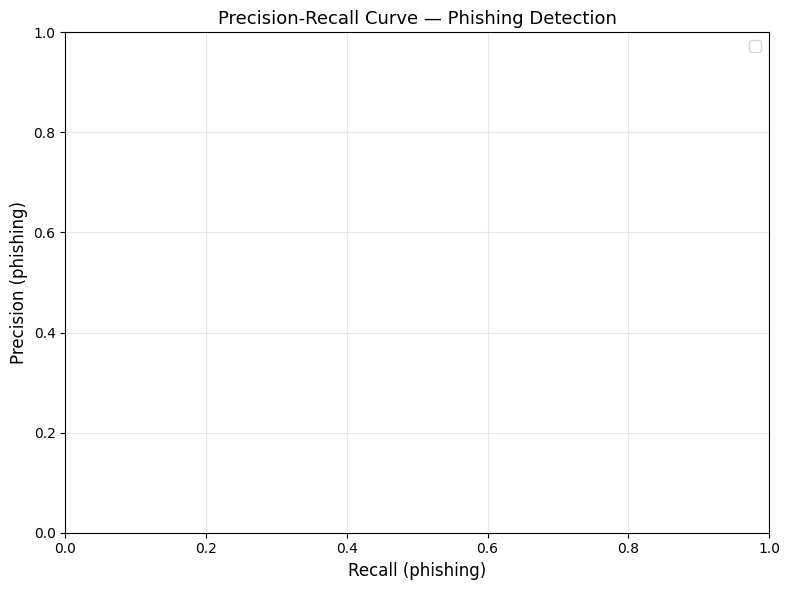

PR curve saved to: /content/drive/MyDrive/qwen3_explainable_runs/qwen3_4b_explainable_seed42_20260607_141527/pr_curve.png


In [ ]:
# ── Precision-Recall curves ──────────────────────────────────────────────────
def plot_pr_curve(eval_results, label, color, ax):
    confs   = eval_results.get("confidences", [])
    y_true_ = eval_results.get("y_true", [])
    valid   = [(c, t) for c, t in zip(confs, y_true_) if c is not None]
    if len(valid) < 2:
        print(f"Not enough confidence scores to plot PR curve for {label}.")
        return None
    cv, tv  = zip(*valid)
    prec, rec, _ = precision_recall_curve(list(tv), list(cv))
    auc_pr        = average_precision_score(list(tv), list(cv))
    ax.plot(rec, prec, color=color, lw=2, label=f"{label} (AUC-PR = {auc_pr:.3f})")
    return auc_pr

fig, ax = plt.subplots(figsize=(8, 6))
if zeroshot_eval_results:
    plot_pr_curve(zeroshot_eval_results, "Zero-shot baseline", "steelblue", ax)
plot_pr_curve(tuned_eval_results, "Fine-tuned QLoRA",    "darkorange",   ax)

# ── Val-optimal operating point on the PR curve ─────────────────────────────
_op_confs  = tuned_eval_results.get("confidences", [])
_op_ytrue  = tuned_eval_results.get("y_true", [])
_op_valid  = [(c, t) for c, t in zip(_op_confs, _op_ytrue) if c is not None]
if _op_valid:
    _op_cv, _op_tv = zip(*_op_valid)
    _op_preds = [1 if c >= PHISHING_THRESHOLD else 0 for c in _op_cv]
    _op_tp = sum(p == 1 and t == 1 for p, t in zip(_op_preds, _op_tv))
    _op_fp = sum(p == 1 and t == 0 for p, t in zip(_op_preds, _op_tv))
    _op_fn = sum(p == 0 and t == 1 for p, t in zip(_op_preds, _op_tv))
    _op_pr = _op_tp / (_op_tp + _op_fp) if (_op_tp + _op_fp) else 0.0
    _op_re = _op_tp / (_op_tp + _op_fn) if (_op_tp + _op_fn) else 0.0
    ax.scatter([_op_re], [_op_pr], color="darkorange", s=150, zorder=5,
               marker="*",
               label=f"Val-optimal threshold = {PHISHING_THRESHOLD:.2f} "
                     f"(P={_op_pr:.3f} R={_op_re:.3f})")


ax.set_xlabel("Recall (phishing)", fontsize=12)
ax.set_ylabel("Precision (phishing)", fontsize=12)
ax.set_title("Precision-Recall Curve — Phishing Detection", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

pr_curve_path = RUN_DIR / "pr_curve.png"
plt.savefig(str(pr_curve_path), dpi=150)
plt.show()
print("PR curve saved to:", pr_curve_path)


In [ ]:
# ── Classical ML baselines + Learning Curves ────────────────────────────────
# Trains 3 classical ML models on the same 126 numerical features used by the LLM
# and plots learning curves (train/val F1 vs training set size).

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.pipeline import Pipeline

# ── Build feature matrix from existing HuggingFace dataset splits ────────────
def dataset_to_xy(ds):
    rows = list(ds)
    # Keep only numeric features (e.g. url.file_extension is a string — excluded)
    feat_names = sorted(
        k for k, v in rows[0]["features"].items()
        if isinstance(v, (int, float, bool))
    )
    X = np.array([[float(r["features"].get(k, 0) or 0) for k in feat_names] for r in rows], dtype=np.float32)
    y = np.array([1 if r["label"] == "phishing" else 0 for r in rows], dtype=np.int32)
    return X, y, feat_names

print("Extracting features from splits...")
X_train, y_train, feat_names = dataset_to_xy(train)
X_test,  y_test,  _          = dataset_to_xy(test)
print(f"  Train: {X_train.shape} | Test: {X_test.shape} | Features: {len(feat_names)}")

# ── Define classifiers ────────────────────────────────────────────────────────
classifiers = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=SEED
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=100, max_depth=4, learning_rate=0.1, random_state=SEED
    ),
}
COLORS = {
    "Logistic Regression":    "#4e79a7",
    "Random Forest":          "#f28e2b",
    "Hist Gradient Boosting": "#e15759",
}

# ── Fit on full train, evaluate on test ──────────────────────────────────────
print("\nClassical ML — Test set performance:")
print(f"{'Model':<26} {'F1':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7}")
print("-" * 56)
clf_test_f1 = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1   = f1_score(y_test, preds)
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    clf_test_f1[name] = f1
    print(f"{name:<26} {f1:>7.4f} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f}")

# ── Learning curves (5-fold CV on training set) ──────────────────────────────
TRAIN_SIZES = np.linspace(0.05, 1.0, 10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(
    "Learning Curves — Classical ML Baselines (F1, 5-fold CV on train set)",
    fontsize=13, y=1.02
)

for ax, (name, clf) in zip(axes, classifiers.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        clf, X_train, y_train,
        train_sizes=TRAIN_SIZES,
        cv=5,
        scoring="f1",
        n_jobs=-1,
        shuffle=True,
        random_state=SEED,
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    color = COLORS[name]

    ax.plot(train_sizes_abs, train_mean, "o-", color=color, label="Train F1")
    ax.fill_between(
        train_sizes_abs,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15, color=color
    )
    ax.plot(train_sizes_abs, val_mean, "s--", color=color, alpha=0.7, label="Val F1 (CV)")
    ax.fill_between(
        train_sizes_abs,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.10, color=color
    )

    # Reference lines from LLM evaluation (if available)
    if tuned_eval_results:
        qwen_f1 = tuned_eval_results.get("classification", {}).get("f1")
        if qwen_f1:
            ax.axhline(
                qwen_f1, color="green", linestyle=":", linewidth=1.8,
                label=f"Qwen3-4B tuned ({qwen_f1:.3f})"
            )
    if zeroshot_eval_results:
        zs_f1 = zeroshot_eval_results.get("classification", {}).get("f1")
        if zs_f1:
            ax.axhline(
                zs_f1, color="gray", linestyle=":", linewidth=1.4,
                label=f"Qwen3-4B zero-shot ({zs_f1:.3f})"
            )

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Training examples")
    if ax is axes[0]:
        ax.set_ylabel("F1 Score")
    ax.set_ylim(0.4, 1.02)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Save results for combined plot
lc_data_classical = {}
for name, clf in classifiers.items():
    ts, tr_sc, val_sc = learning_curve(
        clf, X_train, y_train,
        train_sizes=TRAIN_SIZES, cv=5, scoring="f1",
        n_jobs=-1, shuffle=True, random_state=SEED,
    )
    lc_data_classical[name] = {
        "train_sizes": ts,
        "val_mean":    val_sc.mean(axis=1),
        "val_std":     val_sc.std(axis=1),
        "test_f1":     clf_test_f1[name],
    }
print("lc_data_classical saved — ready for combined plot.")

plt.tight_layout()
lc_path = RUN_DIR / "learning_curves_classical_ml.png"
plt.savefig(lc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {lc_path}")


In [ ]:
# ── LLM Learning Curve + Combined Plot ─────────────────────────────────────
# Trains Qwen3-4B at multiple fractions of the training set and plots F1 vs n_train.
# Gated by RUN_LLM_LEARNING_CURVE (set in Config cell). Each fraction takes ~1h on Colab A100.
# Classical ML results (lc_data_classical) from the previous cell are overlaid for comparison.

llm_lc_results = []

if RUN_LLM_LEARNING_CURVE:
    print(f"Starting LLM learning curve: {LLM_LC_FRACTIONS} fractions on {len(train)} train examples")
    print(f"Estimated time: ~{len(LLM_LC_FRACTIONS)} h on Colab A100\n")

    for frac in LLM_LC_FRACTIONS:
        n_frac   = int(len(train) * frac)
        frac_dir = RUN_DIR / f"lc_frac_{int(frac*100):03d}"
        frac_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n{'='*60}")
        print(f"Fraction {frac:.0%} → {n_frac} training examples")
        print(f"{'='*60}")

        # Sub-sample and tokenize
        train_sub     = train.shuffle(seed=SEED).select(range(n_frac))
        train_tok_sub = train_sub.map(
            tokenize_mask_prompt_raw,
            remove_columns=train_sub.column_names,
            features=_TOK_FEATURES, num_proc=1,
        )
        train_tok_sub = train_tok_sub.filter(lambda x: x["target_token_count"] > 0)
        print(f"  Tokenised: {len(train_tok_sub)} examples")

        # Fresh LoRA on frozen base model
        lora_frac = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=32, lora_alpha=64, lora_dropout=0.05,
            target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
        )
        model_frac = get_peft_model(base_model, lora_frac)
        model_frac.enable_input_require_grads()

        # Training args (same hyperparams as main run, eval per epoch for speed)
        eff_batch_frac = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
        steps_ep_frac  = max(1, len(train_tok_sub) // eff_batch_frac)
        args_frac = TrainingArguments(
            output_dir=str(frac_dir / "checkpoints"),
            per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
            per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
            gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
            num_train_epochs=NUM_TRAIN_EPOCHS,
            learning_rate=LEARNING_RATE,
            warmup_steps=max(5, steps_ep_frac // 10),
            lr_scheduler_type="cosine",
            eval_strategy="epoch",
            save_strategy="no",
            load_best_model_at_end=False,
            bf16=(compute_dtype == torch.bfloat16),
            fp16=(compute_dtype == torch.float16),
            report_to="none",
            optim="paged_adamw_8bit",
            gradient_checkpointing=True,
        )
        trainer_frac = Trainer(
            model=model_frac,
            args=args_frac,
            train_dataset=train_tok_sub,
            eval_dataset=val_tok,
            data_collator=collator,
            callbacks=[EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE,
                early_stopping_threshold=1e-4,
            )] if args_frac.load_best_model_at_end else [],
        )
        trainer_frac.train()

        # Evaluate on test
        eval_frac = run_explainable_evaluation(
            model_obj=model_frac,
            dataset=test,
            run_name=f"lc_frac_{int(frac*100):03d}",
            model_variant="tuned",
            adapter_path=None,
            max_samples=TUNED_EVAL_MAX_SAMPLES,
            include_signals_in_prompt=INCLUDE_SIGNALS_IN_EVAL_PROMPT,
        )
        f1_frac = eval_frac.get("classification", {}).get("f1", 0.0)
        llm_lc_results.append({"frac": frac, "n": n_frac, "f1": f1_frac})
        print(f"  → F1 = {f1_frac:.4f}")

        # Free VRAM between runs
        del model_frac, trainer_frac, train_tok_sub
        gc.collect()
        torch.cuda.empty_cache()

    print("\nLLM learning curve complete:")
    for r in llm_lc_results:
        print(f"  n={r['n']:>6} ({r['frac']:.0%})  F1={r['f1']:.4f}")

else:
    print("RUN_LLM_LEARNING_CURVE=False — LLM curve skipped.")
    print("Set to True in Config cell to enable (adds ~1h per fraction on Colab A100).")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Learning Curves — Classical ML vs Qwen3-4B (Test F1)", fontsize=13)

# Classical ML: continuous curves from CV
ml_linestyles = ["-", "--", ":"]
for (name, data), ls in zip(lc_data_classical.items(), ml_linestyles):
    color = COLORS[name]
    ax.plot(
        data["train_sizes"], data["val_mean"],
        ls, color=color, lw=2, label=f"{name} (test F1={data['test_f1']:.3f})"
    )
    ax.fill_between(
        data["train_sizes"],
        data["val_mean"] - data["val_std"],
        data["val_mean"] + data["val_std"],
        alpha=0.12, color=color
    )

# LLM: discrete points (if available)
if llm_lc_results:
    llm_ns  = [r["n"]  for r in llm_lc_results]
    llm_f1s = [r["f1"] for r in llm_lc_results]
    ax.plot(llm_ns, llm_f1s, "D-", color="green", lw=2.5, ms=9,
            label=f"Qwen3-4B QLoRA (final={llm_f1s[-1]:.3f})")
elif tuned_eval_results:
    # Full-data Qwen3-4B point only
    qwen_f1 = tuned_eval_results.get("classification", {}).get("f1")
    if qwen_f1:
        ax.scatter([len(train)], [qwen_f1], color="green", marker="D", s=100, zorder=5,
                   label=f"Qwen3-4B QLoRA @ full train ({qwen_f1:.3f})")

# Zero-shot reference
if zeroshot_eval_results:
    zs_f1 = zeroshot_eval_results.get("classification", {}).get("f1")
    if zs_f1:
        ax.axhline(zs_f1, color="gray", linestyle=":", lw=1.5,
                   label=f"Qwen3-4B zero-shot ({zs_f1:.3f})")

ax.set_xlabel("Training examples", fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0.4, 1.02)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
combined_path = RUN_DIR / "learning_curve_combined.png"
plt.savefig(combined_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {combined_path}")


In [ ]:
def build_gold_test_candidates(eval_rows, sample_size=100, seed=42):
    rng = random.Random(seed)
    ph  = [r for r in eval_rows if r["ground_truth_label"] == "phishing"]
    be  = [r for r in eval_rows if r["ground_truth_label"] == "benign"]
    rng.shuffle(ph); rng.shuffle(be)
    per_class = max(1, sample_size // 2)
    sample    = ph[:per_class] + be[:per_class]
    remaining = [r for r in eval_rows if r not in sample]
    rng.shuffle(remaining)
    sample.extend(remaining[:max(0, sample_size - len(sample))])
    rng.shuffle(sample)
    return sample[:sample_size]

gold_candidates = build_gold_test_candidates(
    tuned_eval_results["per_example_rows"], sample_size=GOLD_SAMPLE_SIZE, seed=SEED
)
gold_rows = []
for row in gold_candidates:
    gold_rows.append({
        "id":                       row.get("example_id"),
        "url":                      row.get("url"),
        "ground_truth_label":       row.get("ground_truth_label"),
        "model_predicted_label":    row.get("predicted_label"),
        "phishing_confidence":      row.get("phishing_confidence"),
        "clean_text":               row.get("clean_text"),
        "model_output":             row.get("raw_model_output"),
        "reference_explanation":    row.get("reference_explanation"),
        "ground_truth_suspicious_features": row.get("ground_truth_suspicious_features"),
        "ground_truth_benign_features":     row.get("ground_truth_benign_features"),
        "predicted_suspicious_features":    row.get("predicted_suspicious_features"),
        "predicted_benign_features":        row.get("predicted_benign_features"),
        "faithfulness_score":       row.get("faithfulness_score"),
        "taxonomy_compliance":      row.get("taxonomy_compliance"),
        "out_of_taxonomy_features": row.get("out_of_taxonomy_features"),
        "annotation": {
            "final_label": "",
            "label_correct": "",
            "supported_suspicious_features": [],
            "supported_benign_features": [],
            "hallucinated_features": [],
            "missing_important_features": [],
            "rationale_quality": "",      # "good" | "ok" | "poor"
            "faithfulness": "",           # "faithful" | "partly" | "hallucinated"
            "notes": "",
        },
    })

gold_path = RUN_DIR / "gold_test_candidates.jsonl"
with open(gold_path, "w", encoding="utf-8") as fout:
    for row in gold_rows: fout.write(json.dumps(row, ensure_ascii=False) + "\n")

print("Gold test candidates saved to:", gold_path)
print(f"Gold sample: {len(gold_rows)} examples ({sum(1 for r in gold_rows if r['ground_truth_label']=='phishing')} phishing / {sum(1 for r in gold_rows if r['ground_truth_label']=='benign')} benign)")


In [ ]:
# ── Auto-generate model card (adapter/README.md) ─────────────────────────────
def generate_model_card(run_name, model_id, lora_r, lora_alpha, lora_dropout,
                         n_train, n_val, n_test, n_epochs_run, eval_summary,
                         zs_summary, output_path):
    cls = eval_summary.get("classification", {})
    expl = eval_summary.get("explanation", {})
    div  = eval_summary.get("rationale_diversity", {})
    pf   = eval_summary.get("parse_failures", {})

    zs_block = ""
    if zs_summary:
        zc  = zs_summary.get("classification", {})
        zs_block = f"""
### Zero-shot baseline (Qwen3-4B, no adapter)
| Metric | Value |
|--------|-------|
| Accuracy | {zc.get('accuracy', 'N/A'):.4f} |
| Precision | {zc.get('precision', 'N/A'):.4f} |
| Recall | {zc.get('recall', 'N/A'):.4f} |
| F1 | {zc.get('f1', 'N/A'):.4f} |
| AUC-PR | {zc.get('auc_pr') if zc.get('auc_pr') is not None else 'N/A'} |
"""

    card = f"""---
base_model: {model_id}
library_name: peft
pipeline_tag: text-generation
tags:
  - base_model:adapter:{model_id}
  - lora
  - phishing-detection
  - explainability
  - cybersecurity
---

# Explainable Phishing Detector — {run_name}

Fine-tuned **{model_id}** with QLoRA to classify webpages as phishing or benign
**and** generate structured, evidence-grounded explanations for each verdict.

## Model Details

| Field | Value |
|-------|-------|
| Base model | `{model_id}` |
| PEFT method | QLoRA (4-bit NF4, double quant) |
| LoRA rank | {lora_r} |
| LoRA alpha | {lora_alpha} |
| LoRA dropout | {lora_dropout} |
| Target modules | q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj |
| Max sequence length | {MAX_LEN} |
| Training epochs (actual) | {n_epochs_run:.2f} |
| Early stopping patience | {EARLY_STOPPING_PATIENCE} evals |

## Training Data

- **Source:** `50k.jsonl` (147,524-row phishing/benign webpage feature dataset)
- **Balance:** Strict 50/50 (phishing vs benign) — {n_train} train / {n_val} val / {n_test} test
- **Input:** URL, hostname, page title, structured numerical features (126 feature groups)
- **Target:** Structured explanation (feature lists + rationale) followed by verdict token
- **Leakage control:** No pre-extracted signals provided during inference

## Output Format

```
Suspicious features:
- <feature_id>

Benign features:
- <feature_id>

Rationale:
<1-3 evidence-grounded sentences>

Verdict: phishing  # or: Verdict: benign
```

## Evaluation Results (Fine-tuned, {n_test} held-out examples)

### Classification
| Metric | Value |
|--------|-------|
| Accuracy | {cls.get('accuracy', 0):.4f} |
| Precision (phishing) | {cls.get('precision', 0):.4f} |
| Recall (phishing) | {cls.get('recall', 0):.4f} |
| F1 | {cls.get('f1', 0):.4f} |
| AUC-PR | {cls.get('auc_pr') if cls.get('auc_pr') is not None else 'N/A'} |

### Explanation Quality
| Metric | Value |
|--------|-------|
| Feature-grounding F1 (combined) | {expl.get('feature_grounding', dict()).get('combined_f1', 0):.4f} |
| ROUGE-L | {expl.get('text_quality', dict()).get('rouge_l', 0):.4f} |
| BLEU | {expl.get('text_quality', dict()).get('bleu', 0):.4f} |
| Mean faithfulness score | {expl.get('faithfulness', dict()).get('mean_faithfulness', 0):.4f} |
| Taxonomy compliance | {expl.get('taxonomy', dict()).get('mean_compliance', 0):.4f} |
| Contradiction rate | {expl.get('consistency', dict()).get('contradiction_rate', 0):.4f} |
| Parse failure rate | {pf.get('count', 0)}/{eval_summary.get('dataset', dict()).get('num_examples',1)} |
| Template rate (rationale diversity) | {div.get('template_rate', 0):.4f} |
{zs_block}
## Known Limitations

- Recall on phishing is below precision — the model may miss novel phishing patterns.
- Some rationale text shows template-like repetition for benign pages; the diversity metric tracks this.
- Evaluated on a single dataset distribution; performance on out-of-distribution phishing may differ.
- 4-bit quantisation may introduce minor accuracy degradation vs full-precision inference.
- The 50/50 class balance does not reflect real-world phishing base rates.

## Feature Taxonomy

The model is trained to produce feature IDs from a defined taxonomy of {len(KNOWN_FEATURE_TAXONOMY)} identifiers
(e.g., `credential.password_input_present`, `brand.title_domain_mismatch`, `redirect.cross_domain`).
The taxonomy compliance metric reports what fraction of generated features are in this set.

## Framework

- PEFT {lora_alpha} / Transformers / BitsAndBytes / Hugging Face Trainer
- Trained on Google Colab with A100/V100 GPU
"""
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(card)
    print("Model card written to:", output_path)


generate_model_card(
    run_name      = RUN_NAME,
    model_id      = MODEL_ID,
    lora_r        = lora.r,
    lora_alpha    = lora.lora_alpha,
    lora_dropout  = 0.05,
    n_train       = len(train_tok),
    n_val         = len(val_tok),
    n_test        = len(test),
    n_epochs_run  = trainer.state.epoch,
    eval_summary  = tuned_eval_results["summary"],
    zs_summary    = zeroshot_eval_results["summary"] if zeroshot_eval_results else None,
    output_path   = adapter_dir / "README.md",
)


In [ ]:
# ── Deployment bundle ───────────────────────────────────────────────────────
# Saves the exact inference contract needed later:
# URL parser -> 126-feature extractor -> selected feature filter -> prompt -> adapter.

deployment_contract = {
    "base_model_id": MODEL_ID,
    "adapter_dir": str(adapter_dir),
    "tokenizer_dir": str(adapter_dir),
    "selected_features_path": str(selected_features_path),
    "feature_audit_path": str(feature_audit_path),
    "selected_features": SELECTED_FEATURE_NAMES,
    "dropped_features": DROPPED_FEATURE_NAMES,
    "known_feature_taxonomy": sorted(KNOWN_FEATURE_TAXONOMY),
    "phishing_threshold": PHISHING_THRESHOLD,
    "max_len": MAX_LEN,
    "max_clean_text_chars": MAX_CLEAN_TEXT_CHARS,
    "include_signals_in_eval_prompt": INCLUDE_SIGNALS_IN_EVAL_PROMPT,
    "max_signals_in_prompt": MAX_SIGNALS_IN_PROMPT,
    "system_message": SYSTEM_MSG,
    "output_format": {
        "sections": [
            "Phishing risk factors:",
            "Benign mitigating factors:",
            "Reasoning:",
            "Verdict: phishing|benign",
        ],
        "empty_feature_section_value": "- none",
    },
    "required_parser_output": {
        "url": "requested URL string",
        "final_url": "final URL string after redirects when available",
        "title": "page title string",
        "features": "dict containing the same 126 feature names as 50k.jsonl before selected-feature filtering",
    },
    "preprocessing_notes": [
        "Filter raw parser features to selected_features before prompt construction.",
        "Build clean_text with URL, hostname, title, compact selected feature vector, and structured feature summaries.",
        "Do not include precomputed signals in the deployed prompt unless include_signals_in_eval_prompt is true.",
        "Use tokenizer.apply_chat_template with the saved system message and /no_think user prefix.",
    ],
    "final_metrics": tuned_eval_results["summary"],
    "explanation_correctness_report": explanation_correctness_report,
}

deployment_config_path = RUN_DIR / "deployment_contract.json"
adapter_deployment_config_path = adapter_dir / "deployment_contract.json"
with open(deployment_config_path, "w", encoding="utf-8") as _f:
    json.dump(deployment_contract, _f, indent=2, ensure_ascii=False)
with open(adapter_deployment_config_path, "w", encoding="utf-8") as _f:
    json.dump(deployment_contract, _f, indent=2, ensure_ascii=False)

training_config_payload = {
    "model_id": MODEL_ID,
    "run_name": RUN_NAME,
    "seed": SEED,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "actual_epoch": trainer.state.epoch,
    "best_eval_loss": trainer.state.best_metric,
    "best_global_step": trainer.state.best_global_step,
    "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "lora_r": lora.r,
    "lora_alpha": lora.lora_alpha,
    "lora_dropout": 0.05,
    "max_len": MAX_LEN,
    "max_clean_text_chars": MAX_CLEAN_TEXT_CHARS,
    "max_per_subdomain": MAX_PER_SUBDOMAIN,
    "mi_min_score_to_keep": MI_MIN_SCORE_TO_KEEP,
    "mi_missing_rate_drop": MI_MISSING_RATE_DROP,
    "train_rows": len(train_tok),
    "val_rows": len(val_tok),
    "test_rows": len(test),
}
training_config_path = RUN_DIR / "training_config.json"
adapter_training_config_path = adapter_dir / "training_config.json"
with open(training_config_path, "w", encoding="utf-8") as _f:
    json.dump(training_config_payload, _f, indent=2, ensure_ascii=False)
with open(adapter_training_config_path, "w", encoding="utf-8") as _f:
    json.dump(training_config_payload, _f, indent=2, ensure_ascii=False)

print("Deployment contract saved to:", deployment_config_path)
print("Deployment contract copied to:", adapter_deployment_config_path)
print("Training config saved to:", training_config_path)
print("Training config copied to:", adapter_training_config_path)


In [ ]:
# ── Final summary ────────────────────────────────────────────────────────────
summary_payload = {
    "run_dir":          str(RUN_DIR),
    "best_checkpoint":  str(best_ckpt),
    "adapter_dir":      str(adapter_dir),
    "eval_dir":         tuned_eval_results["output_dir"],
    "explanation_correctness_path": str(adapter_dir / "explanation_correctness_report.json"),
    "gold_test_path":   str(RUN_DIR / "gold_test_candidates.jsonl"),
    "pr_curve_path":    str(RUN_DIR / "pr_curve.png"),
    "model_card_path":  str(adapter_dir / "README.md"),
    "deployment_contract_path": str(adapter_dir / "deployment_contract.json"),
    "training_config_path": str(adapter_dir / "training_config.json"),
}
print("\n" + "="*60)
print("RUN COMPLETE")
print("="*60)
print(json.dumps(summary_payload, indent=2, ensure_ascii=False))

if zeroshot_eval_results:
    print_comparison_table(zeroshot_eval_results, tuned_eval_results)
